# Proyek Regression

proyek ini dilakukan untuk perbandingan 3 regresi yang mana dataset yang digunakan adalah (https://www.kaggle.com/datasets/sakhawat18/asteroid-dataset/data)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Regression

/content/drive/MyDrive/Regression


## Import Library

In [3]:
# Main
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

# Outliers
from scipy import stats

# Encoding
from sklearn.preprocessing import LabelEncoder

# For the Model
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# If needed
import itertools
from itertools import combinations
import math

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Regression/dataset.csv")
df

,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.400,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.200,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.330,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.000,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.900,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958519,bPLS6013,3246801,(6013 P-L),6013 P-L,NaN,NaN,N,N,17.135,NaN,...,6.969000e+00,7.433000e+00,4.631100e+01,2.738300e+01,1.041200e+00,1.652100e-01,1.309700e+02,7.264900e+02,MBA,0.23839
958520,bPLS6331,3246834,(6331 P-L),6331 P-L,NaN,NaN,N,N,18.500,NaN,...,1.563500e-05,5.598600e-05,2.380400e-04,1.298200e-04,2.418900e-08,3.346100e-09,4.690200e-04,1.578500e-05,MBA,0.53633
958521,bPLS6344,3013075,(6344 P-L),6344 P-L,NaN,NaN,Y,Y,20.400,NaN,...,1.853300e-05,5.691700e-05,8.969200e-05,5.272600e-05,1.650100e-07,1.101600e-08,2.830600e-04,9.127500e-05,APO,0.51556
958522,bT2S2060,3246457,(2060 T-2),2060 T-2,NaN,NaN,N,N,18.071,NaN,...,5.448800e-01,4.391600e+00,1.898800e+01,1.083800e+01,7.171600e-01,1.016700e-01,3.898400e+01,5.035500e+02,MBA,0.25641


In [6]:
df.shape

(958524, 45)

In [7]:
# Dictionary for renaming columns
rename_dict = {
    'id': 'Asteroid_ID',
    'spkid': 'NASA_SPK_ID',
    'full_name': 'Asteroid_Full_Name',
    'pdes': 'Primary_Designation',
    'name': 'Asteroid_Name',
    'prefix': 'Name_Prefix',
    'neo': 'Near_Earth_Object',
    'pha': 'Potentially_Hazardous',
    'H': 'Brightness',
    'diameter': 'Asteroid_Size_km(Diameter)',
    'albedo': 'Reflectivity',
    'diameter_sigma': 'Size_Uncertainty_km',
    'orbit_id': 'Orbit_Solution_ID',
    'epoch': 'Observation_Date',
    'epoch_mjd': 'Observation_Date_MJD',
    'epoch_cal': 'Observation_Date_Calendar',
    'equinox': 'Reference_Frame',
    'e': 'Orbit_Shape',
    'a': 'Orbit_Distance_AU',
    'q': 'Closest_Sun_Distance_AU',
    'i': 'Orbit_Tilt_Degrees',
    'om': 'Orbit_Angle_1_Degrees',
    'w': 'Orbit_Angle_2_Degrees',
    'ma': 'Orbit_Angle_3_Degrees',
    'ad': 'Farthest_Sun_Distance_AU',
    'n': 'Orbit_Speed_Degrees_Per_Day',
    'tp': 'Closest_Sun_Date',
    'tp_cal': 'Closest_Sun_Date_Calendar',
    'per': 'Orbit_Period_Days',
    'per_y': 'Orbit_Period_Years',
    'moid': 'Earth_Closest_Distance_AU',
    'moid_ld': 'Earth_Closest_Distance_Lunar',
    'sigma_e': 'Uncertainty_Orbit_Shape',
    'sigma_a': 'Uncertainty_Orbit_Distance',
    'sigma_q': 'Uncertainty_Closest_Sun_Distance',
    'sigma_i': 'Uncertainty_Orbit_Tilt',
    'sigma_om': 'Uncertainty_Orbit_Angle_1',
    'sigma_w': 'Uncertainty_Orbit_Angle_2',
    'sigma_ma': 'Uncertainty_Orbit_Angle_3',
    'sigma_ad': 'Uncertainty_Farthest_Sun_Distance',
    'sigma_n': 'Uncertainty_Orbit_Speed',
    'sigma_tp': 'Uncertainty_Closest_Sun_Date',
    'sigma_per': 'Uncertainty_Orbit_Period',
    'class': 'Asteroid_Class',
    'rms': 'Measurement_Error'
}

df.rename(columns=rename_dict, inplace=True)

df

,Asteroid_ID,NASA_SPK_ID,Asteroid_Full_Name,Primary_Designation,Asteroid_Name,Name_Prefix,Near_Earth_Object,Potentially_Hazardous,Brightness,Asteroid_Size_km(Diameter),...,Uncertainty_Orbit_Tilt,Uncertainty_Orbit_Angle_1,Uncertainty_Orbit_Angle_2,Uncertainty_Orbit_Angle_3,Uncertainty_Farthest_Sun_Distance,Uncertainty_Orbit_Speed,Uncertainty_Closest_Sun_Date,Uncertainty_Orbit_Period,Asteroid_Class,Measurement_Error
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.400,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.200,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.330,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.000,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.900,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958519,bPLS6013,3246801,(6013 P-L),6013 P-L,NaN,NaN,N,N,17.135,NaN,...,6.969000e+00,7.433000e+00,4.631100e+01,2.738300e+01,1.041200e+00,1.652100e-01,1.309700e+02,7.264900e+02,MBA,0.23839
958520,bPLS6331,3246834,(6331 P-L),6331 P-L,NaN,NaN,N,N,18.500,NaN,...,1.563500e-05,5.598600e-05,2.380400e-04,1.298200e-04,2.418900e-08,3.346100e-09,4.690200e-04,1.578500e-05,MBA,0.53633
958521,bPLS6344,3013075,(6344 P-L),6344 P-L,NaN,NaN,Y,Y,20.400,NaN,...,1.853300e-05,5.691700e-05,8.969200e-05,5.272600e-05,1.650100e-07,1.101600e-08,2.830600e-04,9.127500e-05,APO,0.51556
958522,bT2S2060,3246457,(2060 T-2),2060 T-2,NaN,NaN,N,N,18.071,NaN,...,5.448800e-01,4.391600e+00,1.898800e+01,1.083800e+01,7.171600e-01,1.016700e-01,3.898400e+01,5.035500e+02,MBA,0.25641


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Asteroid_ID                        958524 non-null  object 
 1   NASA_SPK_ID                        958524 non-null  int64  
 2   Asteroid_Full_Name                 958524 non-null  object 
 3   Primary_Designation                958524 non-null  object 
 4   Asteroid_Name                      22064 non-null   object 
 5   Name_Prefix                        18 non-null      object 
 6   Near_Earth_Object                  958520 non-null  object 
 7   Potentially_Hazardous              938603 non-null  object 
 8   Brightness                         952261 non-null  float64
 9   Asteroid_Size_km(Diameter)         136209 non-null  float64
 10  Reflectivity                       135103 non-null  float64
 11  Size_Uncertainty_km                1360

In [9]:
df.isna().sum()

,0
Asteroid_ID,0
NASA_SPK_ID,0
Asteroid_Full_Name,0
Primary_Designation,0
Asteroid_Name,936460
Name_Prefix,958506
Near_Earth_Object,4
Potentially_Hazardous,19921
Brightness,6263
Asteroid_Size_km(Diameter),822315


In [10]:
# List of non-useful columns
non_useful_columns = [
    'Asteroid_ID', 'NASA_SPK_ID', 'Asteroid_Full_Name', 'Primary_Designation',
    'Asteroid_Name', 'Name_Prefix', 'Size_Uncertainty_km', 'Orbit_Solution_ID',
    'Observation_Date', 'Observation_Date_MJD', 'Observation_Date_Calendar',
    'Reference_Frame', 'Closest_Sun_Date', 'Closest_Sun_Date_Calendar',
    'Uncertainty_Orbit_Shape', 'Uncertainty_Orbit_Distance', 'Uncertainty_Closest_Sun_Distance',
    'Uncertainty_Orbit_Tilt', 'Uncertainty_Orbit_Angle_1', 'Uncertainty_Orbit_Angle_2',
    'Uncertainty_Orbit_Angle_3', 'Uncertainty_Farthest_Sun_Distance', 'Uncertainty_Orbit_Speed',
    'Uncertainty_Closest_Sun_Date', 'Uncertainty_Orbit_Period', 'Measurement_Error'
]

# Drop non-useful columns
df.drop(columns=non_useful_columns, inplace=True)

# Drop one of the redundant columns (keep Earth_Closest_Distance_AU, drop Lunar)
df.drop(columns=['Earth_Closest_Distance_Lunar', 'Orbit_Period_Years'], inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Near_Earth_Object            958520 non-null  object 
 1   Potentially_Hazardous        938603 non-null  object 
 2   Brightness                   952261 non-null  float64
 3   Asteroid_Size_km(Diameter)   136209 non-null  float64
 4   Reflectivity                 135103 non-null  float64
 5   Orbit_Shape                  958524 non-null  float64
 6   Orbit_Distance_AU            958524 non-null  float64
 7   Closest_Sun_Distance_AU      958524 non-null  float64
 8   Orbit_Tilt_Degrees           958524 non-null  float64
 9   Orbit_Angle_1_Degrees        958524 non-null  float64
 10  Orbit_Angle_2_Degrees        958524 non-null  float64
 11  Orbit_Angle_3_Degrees        958523 non-null  float64
 12  Farthest_Sun_Distance_AU     958520 non-null  float64
 13 

In [11]:
df.shape

(958524, 17)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.nunique()

,0
Near_Earth_Object,2
Potentially_Hazardous,2
Brightness,9489
Asteroid_Size_km(Diameter),16591
Reflectivity,1057
Orbit_Shape,958444
Orbit_Distance_AU,958509
Closest_Sun_Distance_AU,958509
Orbit_Tilt_Degrees,958414
Orbit_Angle_1_Degrees,958518


In [14]:
for col in df.columns:
    print(f"Unique values in column '{col}':")
    print(df[col].unique())
    print("-" * 20)

Unique values in column 'Near_Earth_Object':
['N' 'Y' nan]
--------------------
Unique values in column 'Potentially_Hazardous':
['N' 'Y' nan]
--------------------
Unique values in column 'Brightness':
[ 3.4    4.2    5.33  ... 21.51  26.98  26.419]
--------------------
Unique values in column 'Asteroid_Size_km(Diameter)':
[9.39400e+02 5.45000e+02 2.46596e+02 ... 1.22000e-01 6.51000e-01
 1.07700e+00]
--------------------
Unique values in column 'Reflectivity':
[0.09  0.101 0.214 ... 0.009 0.004 0.007]
--------------------
Unique values in column 'Orbit_Shape':
[0.07600903 0.22997226 0.25693643 ... 0.6624461  0.2020528  0.25834823]
--------------------
Unique values in column 'Orbit_Distance_AU':
[2.76916515 2.77384143 2.66828529 ... 2.81715181 2.3731369  2.26040449]
--------------------
Unique values in column 'Closest_Sun_Distance_AU':
[2.5586836  2.13593485 1.98270558 ... 0.95094059 1.89363794 1.67643298]
--------------------
Unique values in column 'Orbit_Tilt_Degrees':
[10.5940672 

## Handling Missing Values

In [15]:
# Count missing values in each row
missing_counts = df.isna().sum(axis=1)

# Identify rows with 2 or more missing values and count them
num_rows_to_delete = (missing_counts >= 2).sum()
print(f"\nTotal number of rows with 2 or more missing values: {num_rows_to_delete}")

# Count occurrences of each missing value count
missing_distribution = missing_counts[missing_counts >= 2].value_counts().sort_index()
print("Distribution of missing values per row:")
print(missing_distribution)


Total number of rows with 2 or more missing values: 822613
Distribution of missing values per row:
2    800589
3      2099
4     19920
5         5
Name: count, dtype: int64


In [16]:
# Calculate missing value percentages
missing_percentages = df.isnull().mean() * 100

# Categorize columns based on missing value percentage ranges
ranges = {
    "0-10%": [],
    "10-20%": [],
    "20-30%": [],
    "30-40%": [],
    "50-50%": [],
    "50-60%": [],
    "60-70%": [],
    "70-80%": [],
    "80-90%": [],
    "90-100%": []
}

for col, perc in missing_percentages.items():
    if 0 <= perc < 10:
        ranges["0-10%"].append(col)
    elif 10 <= perc < 20:
        ranges["10-20%"].append(col)
    elif 20 <= perc < 30:
        ranges["20-30%"].append(col)
    elif 30 <= perc < 40:
        ranges["30-40%"].append(col)
    elif 40 <= perc < 50:
        ranges["40-50%"].append(col)
    elif 50 <= perc < 60:
        ranges["50-60%"].append(col)
    elif 60 <= perc < 70:
        ranges["60-70%"].append(col)
    elif 70 <= perc < 80:
        ranges["70-80%"].append(col)
    elif 80 <= perc < 90:
        ranges["80-90%"].append(col)
    elif 90 <= perc <= 100:
        ranges["90-100%"].append(col)

# Print results
for range_label, cols in ranges.items():
    print(f"Columns with missing values in range {range_label}: {cols}")

Columns with missing values in range 0-10%: ['Near_Earth_Object', 'Potentially_Hazardous', 'Brightness', 'Orbit_Shape', 'Orbit_Distance_AU', 'Closest_Sun_Distance_AU', 'Orbit_Tilt_Degrees', 'Orbit_Angle_1_Degrees', 'Orbit_Angle_2_Degrees', 'Orbit_Angle_3_Degrees', 'Farthest_Sun_Distance_AU', 'Orbit_Speed_Degrees_Per_Day', 'Orbit_Period_Days', 'Earth_Closest_Distance_AU', 'Asteroid_Class']
Columns with missing values in range 10-20%: []
Columns with missing values in range 20-30%: []
Columns with missing values in range 30-40%: []
Columns with missing values in range 50-50%: []
Columns with missing values in range 50-60%: []
Columns with missing values in range 60-70%: []
Columns with missing values in range 70-80%: []
Columns with missing values in range 80-90%: ['Asteroid_Size_km(Diameter)', 'Reflectivity']
Columns with missing values in range 90-100%: []


In [17]:
# Handle columns with low missing values (0-10%)

# Impute categorical columns with the most frequent value (mode)
df['Near_Earth_Object'].fillna(df['Near_Earth_Object'].mode()[0], inplace=True)
df['Potentially_Hazardous'].fillna(df['Potentially_Hazardous'].mode()[0], inplace=True)

# Impute numerical columns with median (using SimpleImputer to avoid issues)
num_cols_to_impute = ['Brightness', 'Orbit_Angle_3_Degrees', 'Farthest_Sun_Distance_AU',
                      'Orbit_Period_Days', 'Earth_Closest_Distance_AU']
imputer = SimpleImputer(strategy='median')
df[num_cols_to_impute] = imputer.fit_transform(df[num_cols_to_impute])

In [18]:
# Create a copy of the DataFrame for regression task
df_regression = df.copy()

# Drop rows with missing Asteroid_Size_km (target)
df_regression.dropna(subset=['Asteroid_Size_km(Diameter)'], inplace=True)

# Impute missing values in the Reflectivity column with the median
df_regression['Reflectivity'].fillna(df_regression['Reflectivity'].median(), inplace=True)

In [19]:
# Count missing values in each row
missing_counts = df_regression.isna().sum(axis=1)

# Identify rows with 2 or more missing values and count them
num_rows_to_delete = (missing_counts >= 2).sum()
print(f"\nTotal number of rows with 2 or more missing values: {num_rows_to_delete}")

# Count occurrences of each missing value count
missing_distribution = missing_counts[missing_counts >= 2].value_counts().sort_index()
print("Distribution of missing values per row:")
print(missing_distribution)


Total number of rows with 2 or more missing values: 0
Distribution of missing values per row:
Series([], Name: count, dtype: int64)


In [20]:
df_regression.isna().sum()

,0
Near_Earth_Object,0
Potentially_Hazardous,0
Brightness,0
Asteroid_Size_km(Diameter),0
Reflectivity,0
Orbit_Shape,0
Orbit_Distance_AU,0
Closest_Sun_Distance_AU,0
Orbit_Tilt_Degrees,0
Orbit_Angle_1_Degrees,0


In [21]:
df_regression.shape

(136209, 17)

In [22]:
df_regression.info()

<class 'pandas.core.frame.DataFrame'>
Index: 136209 entries, 0 to 909489
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Near_Earth_Object            136209 non-null  object 
 1   Potentially_Hazardous        136209 non-null  object 
 2   Brightness                   136209 non-null  float64
 3   Asteroid_Size_km(Diameter)   136209 non-null  float64
 4   Reflectivity                 136209 non-null  float64
 5   Orbit_Shape                  136209 non-null  float64
 6   Orbit_Distance_AU            136209 non-null  float64
 7   Closest_Sun_Distance_AU      136209 non-null  float64
 8   Orbit_Tilt_Degrees           136209 non-null  float64
 9   Orbit_Angle_1_Degrees        136209 non-null  float64
 10  Orbit_Angle_2_Degrees        136209 non-null  float64
 11  Orbit_Angle_3_Degrees        136209 non-null  float64
 12  Farthest_Sun_Distance_AU     136209 non-null  float64
 13  Orbi

## Handling Outliers

In [23]:
outlier_columns = []

for column in df_regression.select_dtypes(include=['number']).columns:
    Q1 = df_regression[column].quantile(0.25)
    Q3 = df_regression[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_regression[(df_regression[column] < lower_bound) | (df_regression[column] > upper_bound)]

    if not outliers.empty:
        outlier_columns.append(column)
        print(f"Column '{column}' has {len(outliers)} outliers.")

print("Columns with outliers:", outlier_columns)

Column 'Brightness' has 3221 outliers.
Column 'Asteroid_Size_km(Diameter)' has 9613 outliers.
Column 'Reflectivity' has 3809 outliers.
Column 'Orbit_Shape' has 1503 outliers.
Column 'Orbit_Distance_AU' has 3423 outliers.
Column 'Closest_Sun_Distance_AU' has 2708 outliers.
Column 'Orbit_Tilt_Degrees' has 4256 outliers.
Column 'Farthest_Sun_Distance_AU' has 3567 outliers.
Column 'Orbit_Speed_Degrees_Per_Day' has 3253 outliers.
Column 'Orbit_Period_Days' has 3399 outliers.
Column 'Earth_Closest_Distance_AU' has 2552 outliers.
Columns with outliers: ['Brightness', 'Asteroid_Size_km(Diameter)', 'Reflectivity', 'Orbit_Shape', 'Orbit_Distance_AU', 'Closest_Sun_Distance_AU', 'Orbit_Tilt_Degrees', 'Farthest_Sun_Distance_AU', 'Orbit_Speed_Degrees_Per_Day', 'Orbit_Period_Days', 'Earth_Closest_Distance_AU']


In [24]:
# 2- Z-Score
outlier_cols_zscore = []

for column in df_regression.select_dtypes(include=['number']).columns:
    z_scores = stats.zscore(df_regression[column].dropna())  # Drop NaN values to avoid errors
    outliers = (abs(z_scores) > 3).sum()

    if outliers > 0:
        outlier_cols_zscore.append(column)
        print(f"Column '{column}' has {outliers} outliers.")

print("Columns with outliers (Z-score):", outlier_cols_zscore)


Column 'Brightness' has 1779 outliers.
Column 'Asteroid_Size_km(Diameter)' has 1262 outliers.
Column 'Reflectivity' has 1460 outliers.
Column 'Orbit_Shape' has 987 outliers.
Column 'Orbit_Distance_AU' has 54 outliers.
Column 'Closest_Sun_Distance_AU' has 2274 outliers.
Column 'Orbit_Tilt_Degrees' has 681 outliers.
Column 'Farthest_Sun_Distance_AU' has 55 outliers.
Column 'Orbit_Speed_Degrees_Per_Day' has 595 outliers.
Column 'Orbit_Period_Days' has 29 outliers.
Column 'Earth_Closest_Distance_AU' has 1915 outliers.
Columns with outliers (Z-score): ['Brightness', 'Asteroid_Size_km(Diameter)', 'Reflectivity', 'Orbit_Shape', 'Orbit_Distance_AU', 'Closest_Sun_Distance_AU', 'Orbit_Tilt_Degrees', 'Farthest_Sun_Distance_AU', 'Orbit_Speed_Degrees_Per_Day', 'Orbit_Period_Days', 'Earth_Closest_Distance_AU']


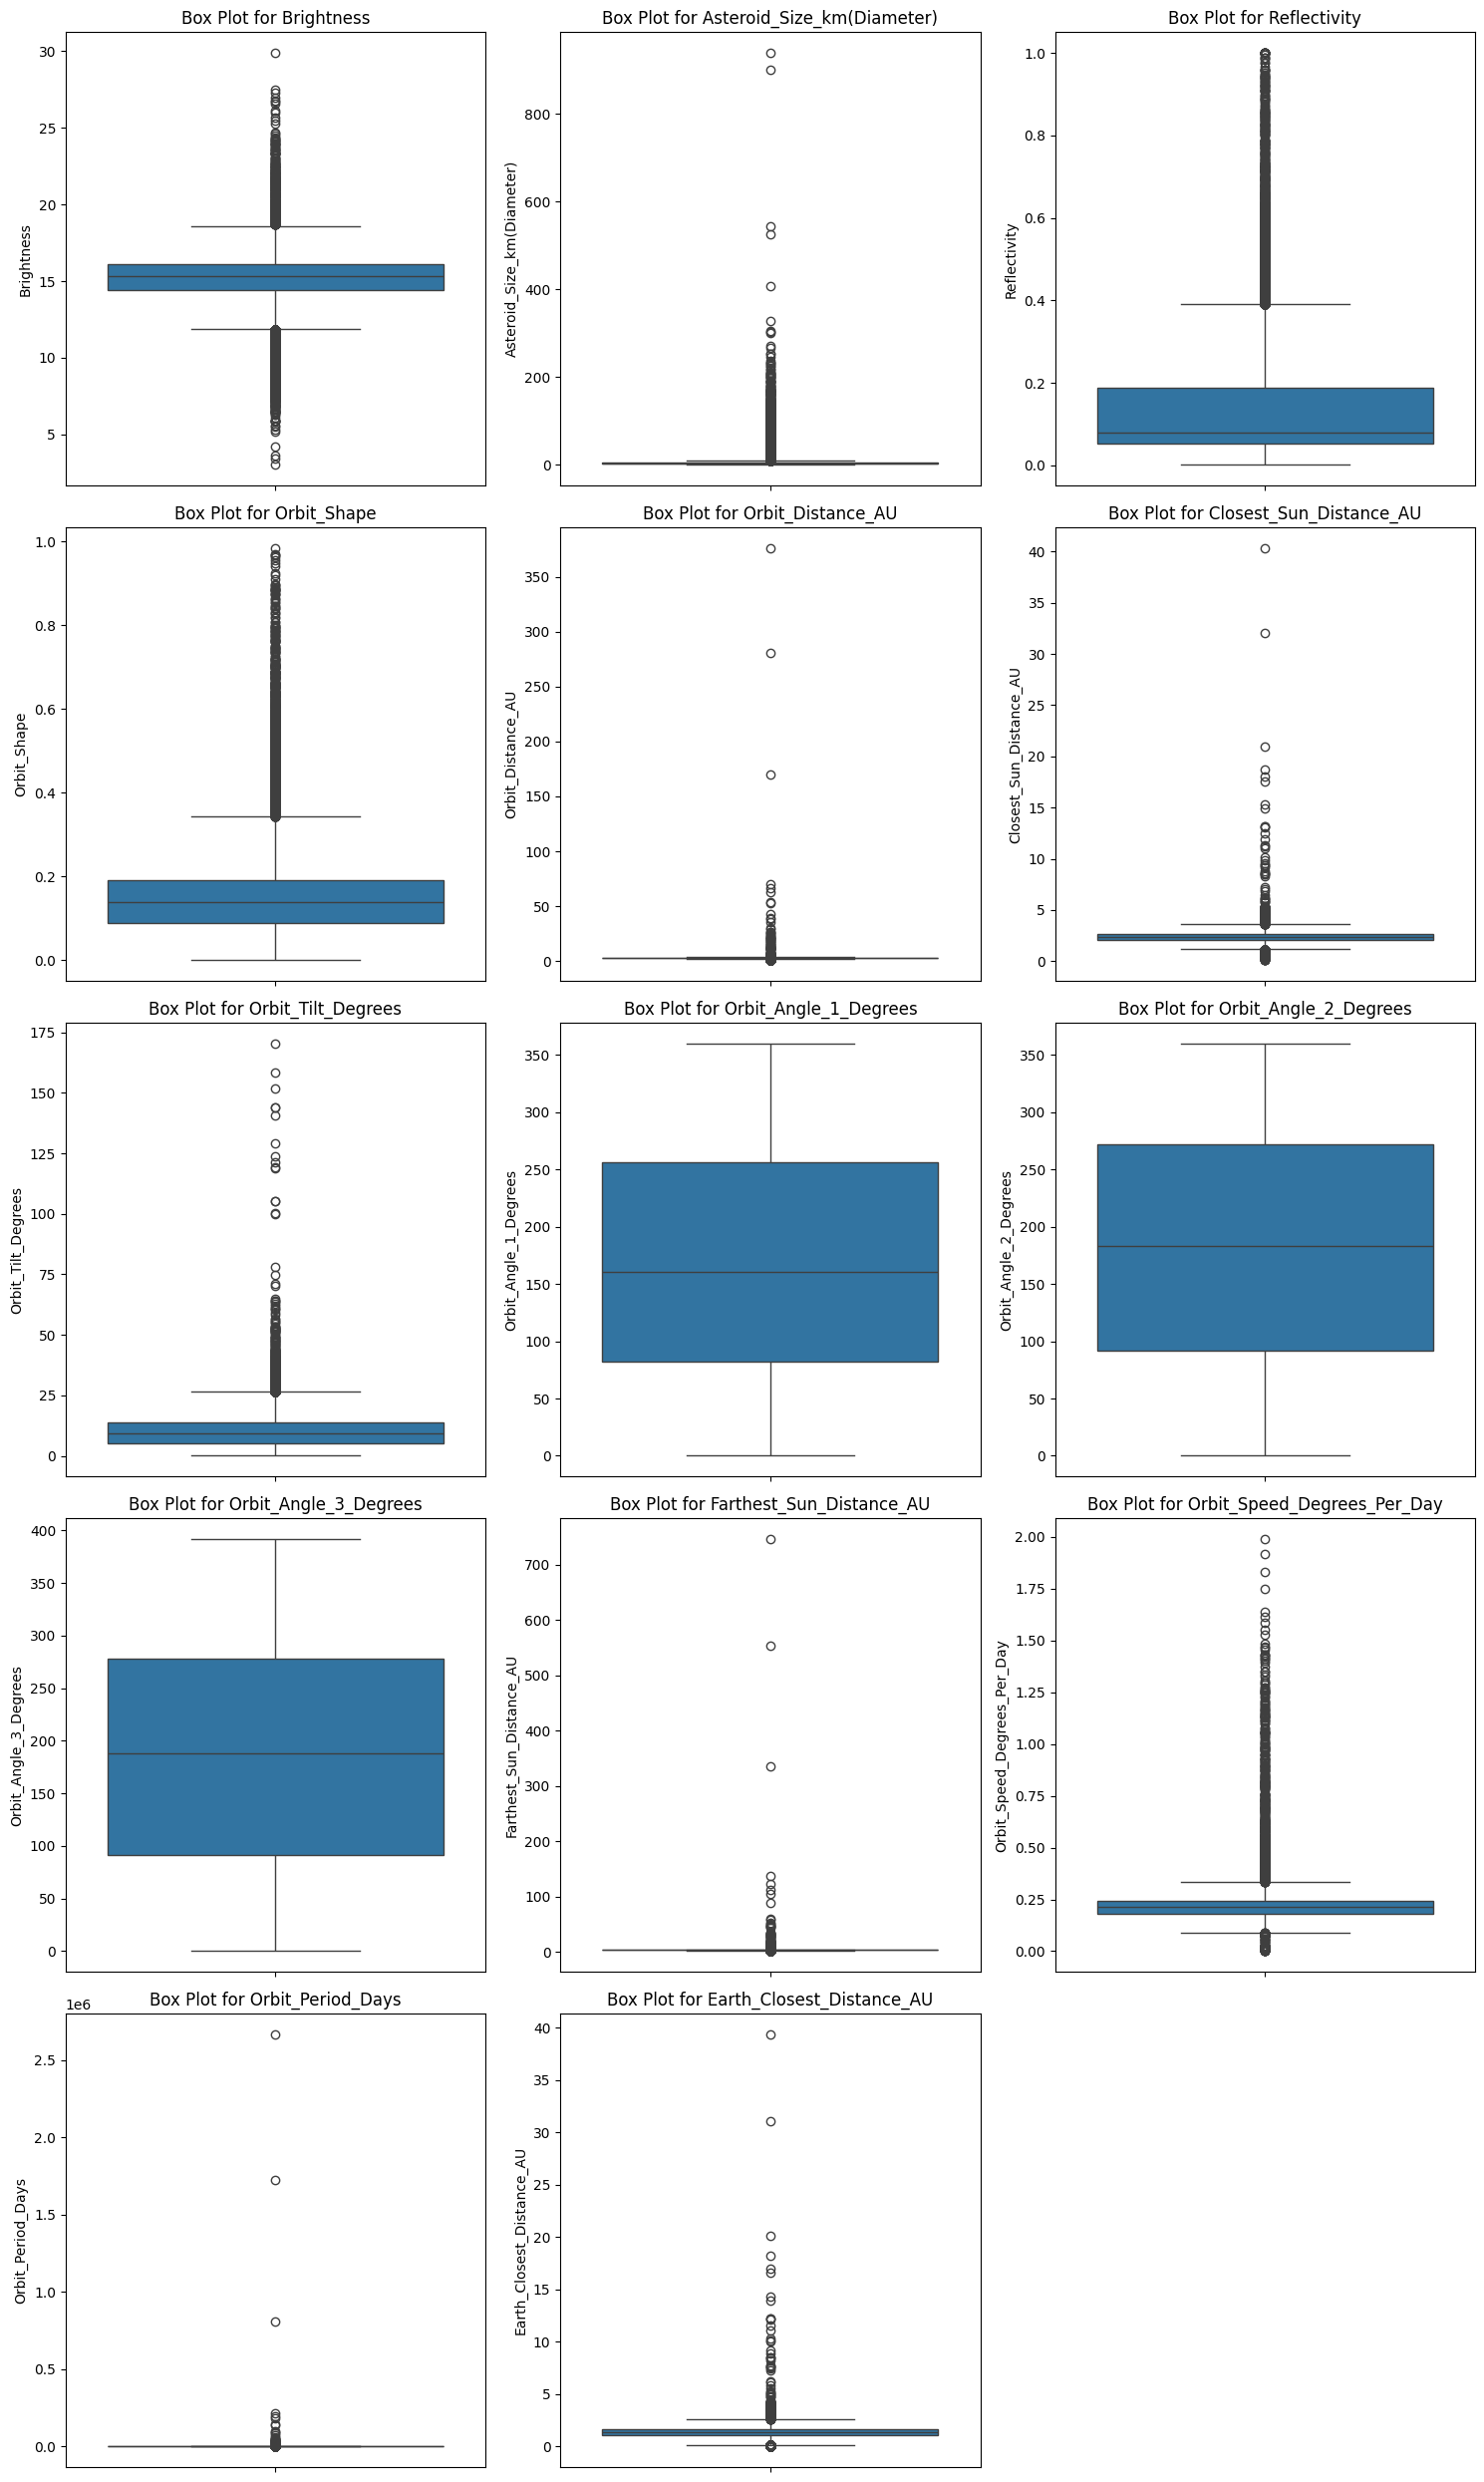

In [25]:
# Select only numerical columns
num_cols = df_regression.select_dtypes(include=['number']).columns

# Define grid layout (e.g., 3 columns and dynamic rows)
n_cols = 3  # Number of columns
n_rows = -(-len(num_cols) // n_cols)  # Ceiling division to calculate rows

# Create subplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 5 * n_rows))

# Flatten axes array if it's 2D
axes = axes.flatten()

# Create box plots for each numerical column
for i, column in enumerate(num_cols):
    sns.boxplot(y=df_regression[column], ax=axes[i])
    axes[i].set_title(f'Box Plot for {column}')

# Hide any empty subplots
for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

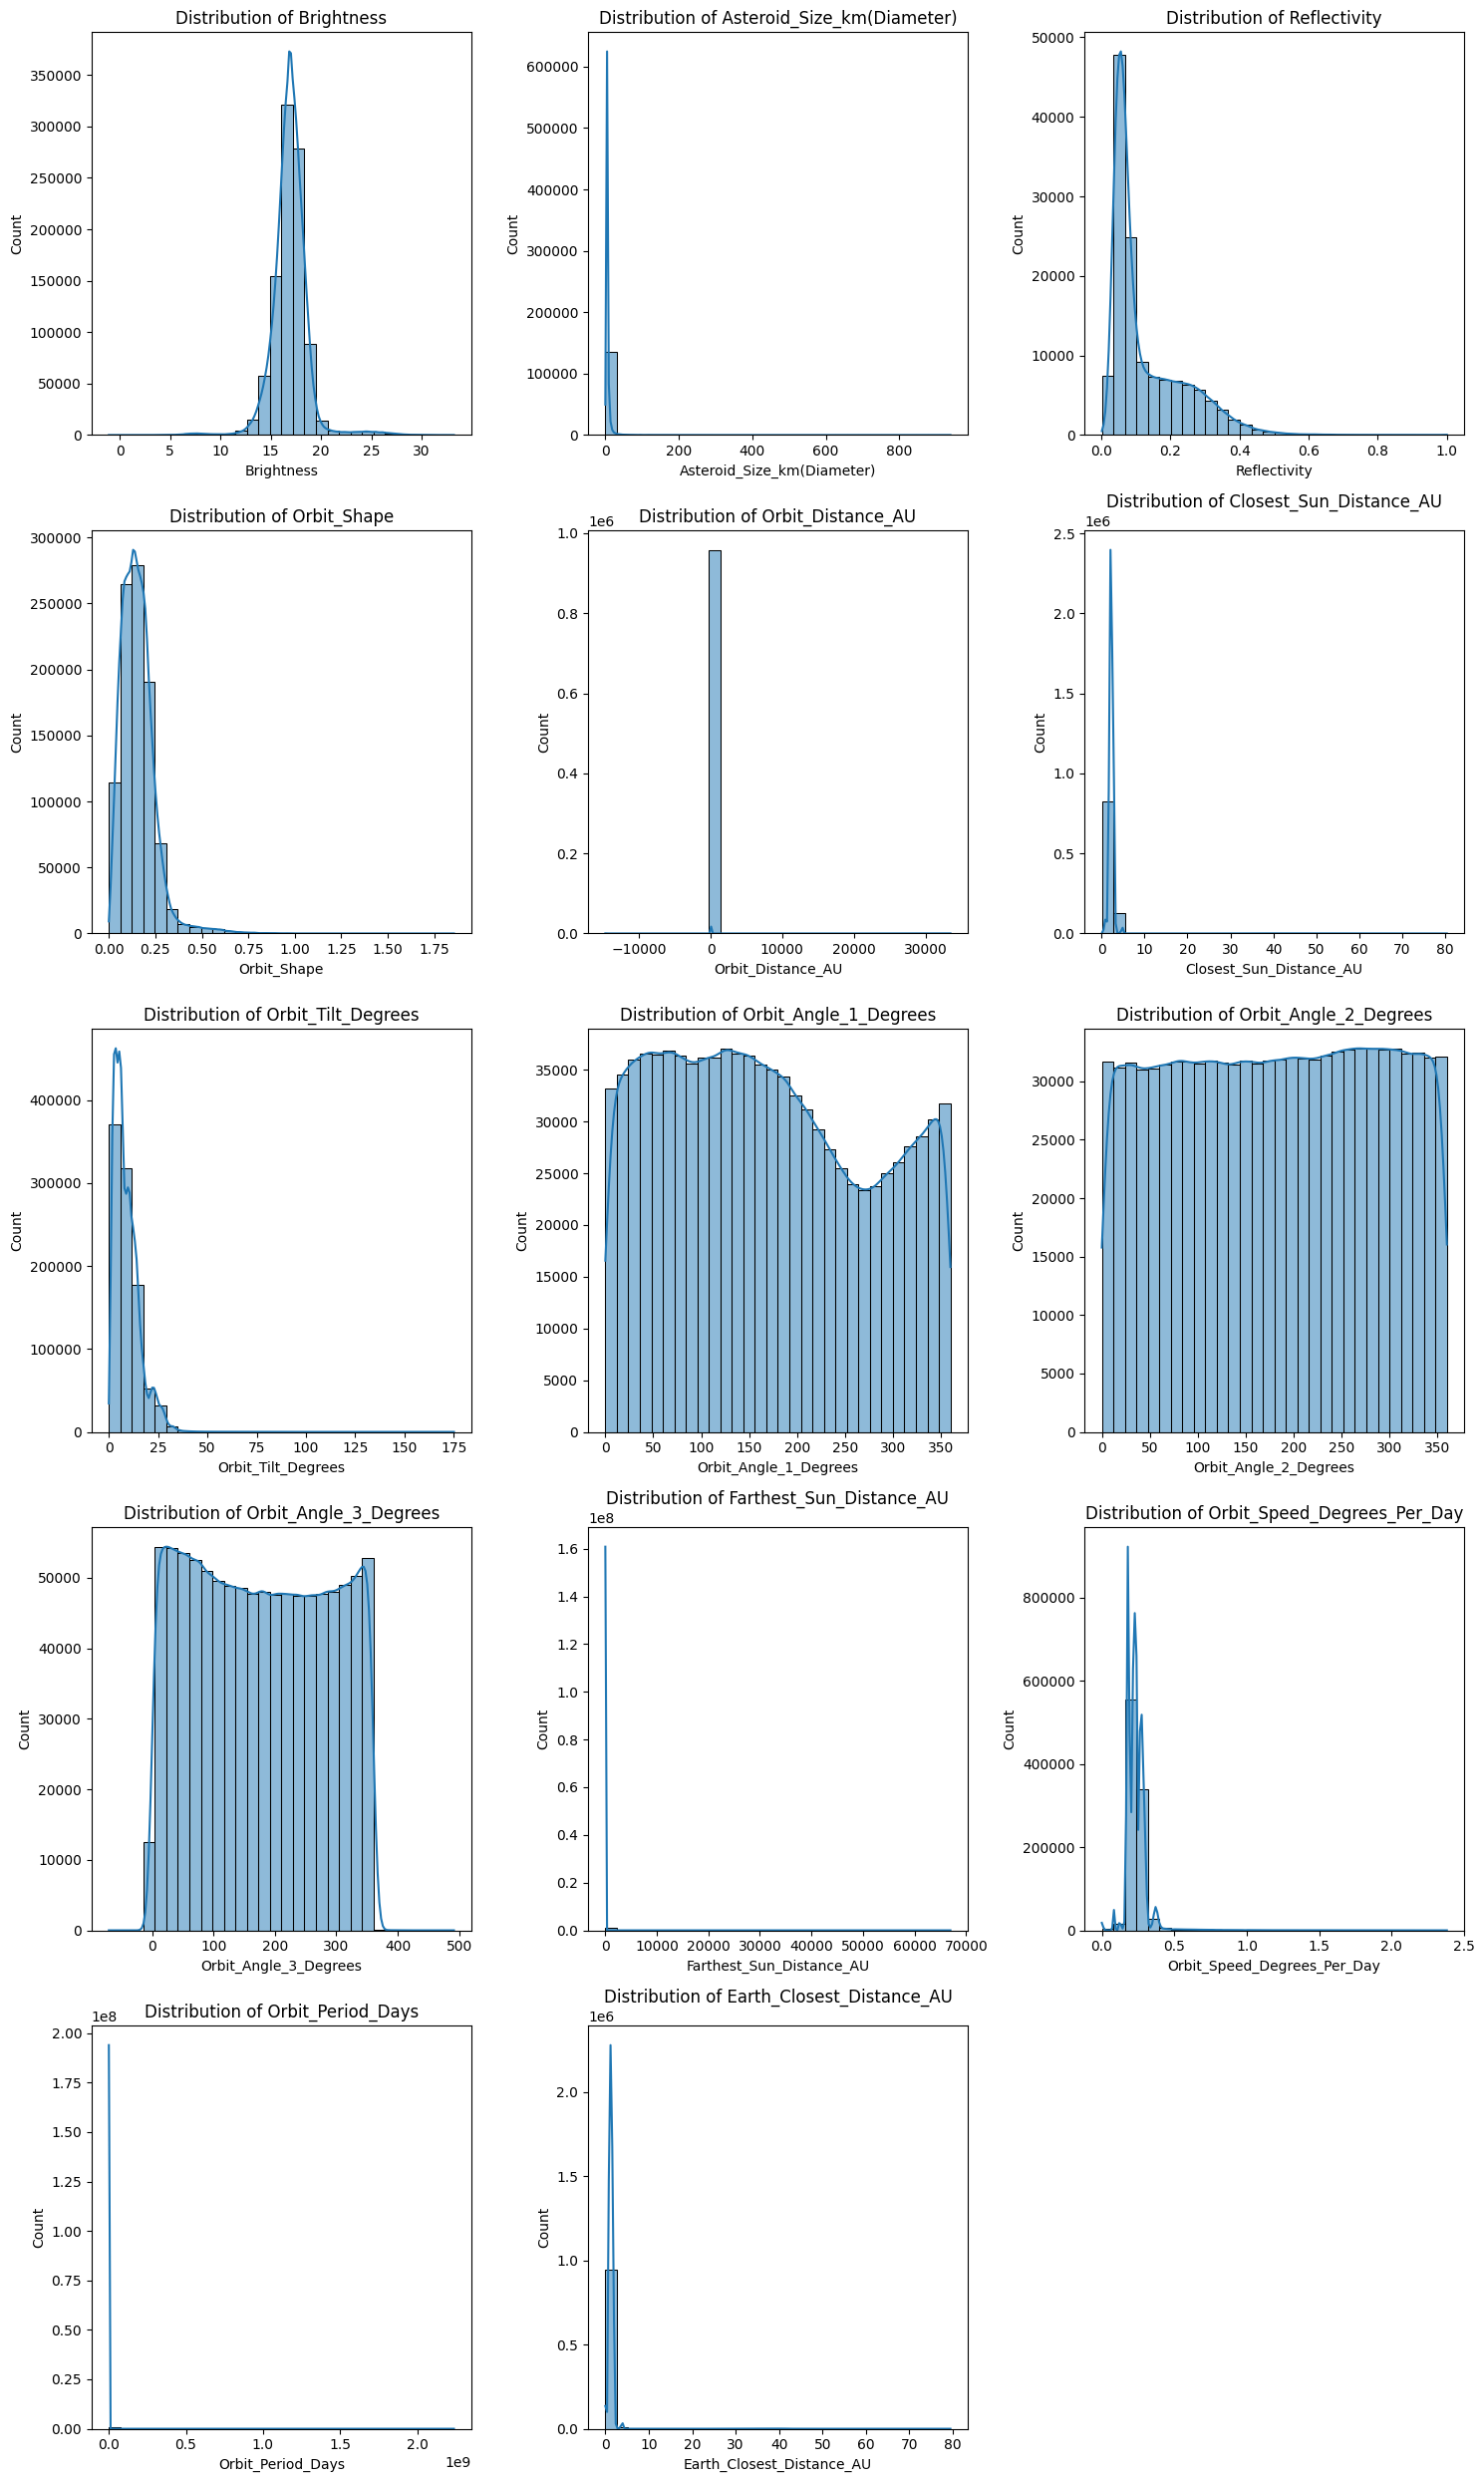

In [26]:
# Define grid layout (e.g., 3 columns and dynamic rows)
n_cols = 3  # Number of columns
n_rows = -(-len(num_cols) // n_cols)  # Ceiling division to calculate rows

# Create subplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 5 * n_rows))

# Flatten axes array if it's 2D
axes = axes.flatten()

# Create histograms for each numerical column
for i, column in enumerate(num_cols):
    sns.histplot(df[column], bins=30, kde=True, ax=axes[i])  # Histogram with KDE
    axes[i].set_title(f'Distribution of {column}')

# Hide any empty subplots
for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [27]:
# Step 1: Clip extreme values in suspected error columns
error_columns = ['Orbit_Distance_AU', 'Farthest_Sun_Distance_AU']
for column in error_columns:
    Q1 = df_regression[column].quantile(0.25)
    Q3 = df_regression[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_regression[column] = df_regression[column].clip(lower=lower_bound, upper=upper_bound)

# Step 2: Log transform the target and skewed features
skewed_columns = ['Asteroid_Size_km(Diameter)', 'Brightness', 'Reflectivity', 'Orbit_Shape',
                  'Closest_Sun_Distance_AU', 'Orbit_Tilt_Degrees', 'Orbit_Speed_Degrees_Per_Day',
                  'Orbit_Period_Days', 'Earth_Closest_Distance_AU']
for column in skewed_columns:
    df_regression[column] = np.log1p(df_regression[column])

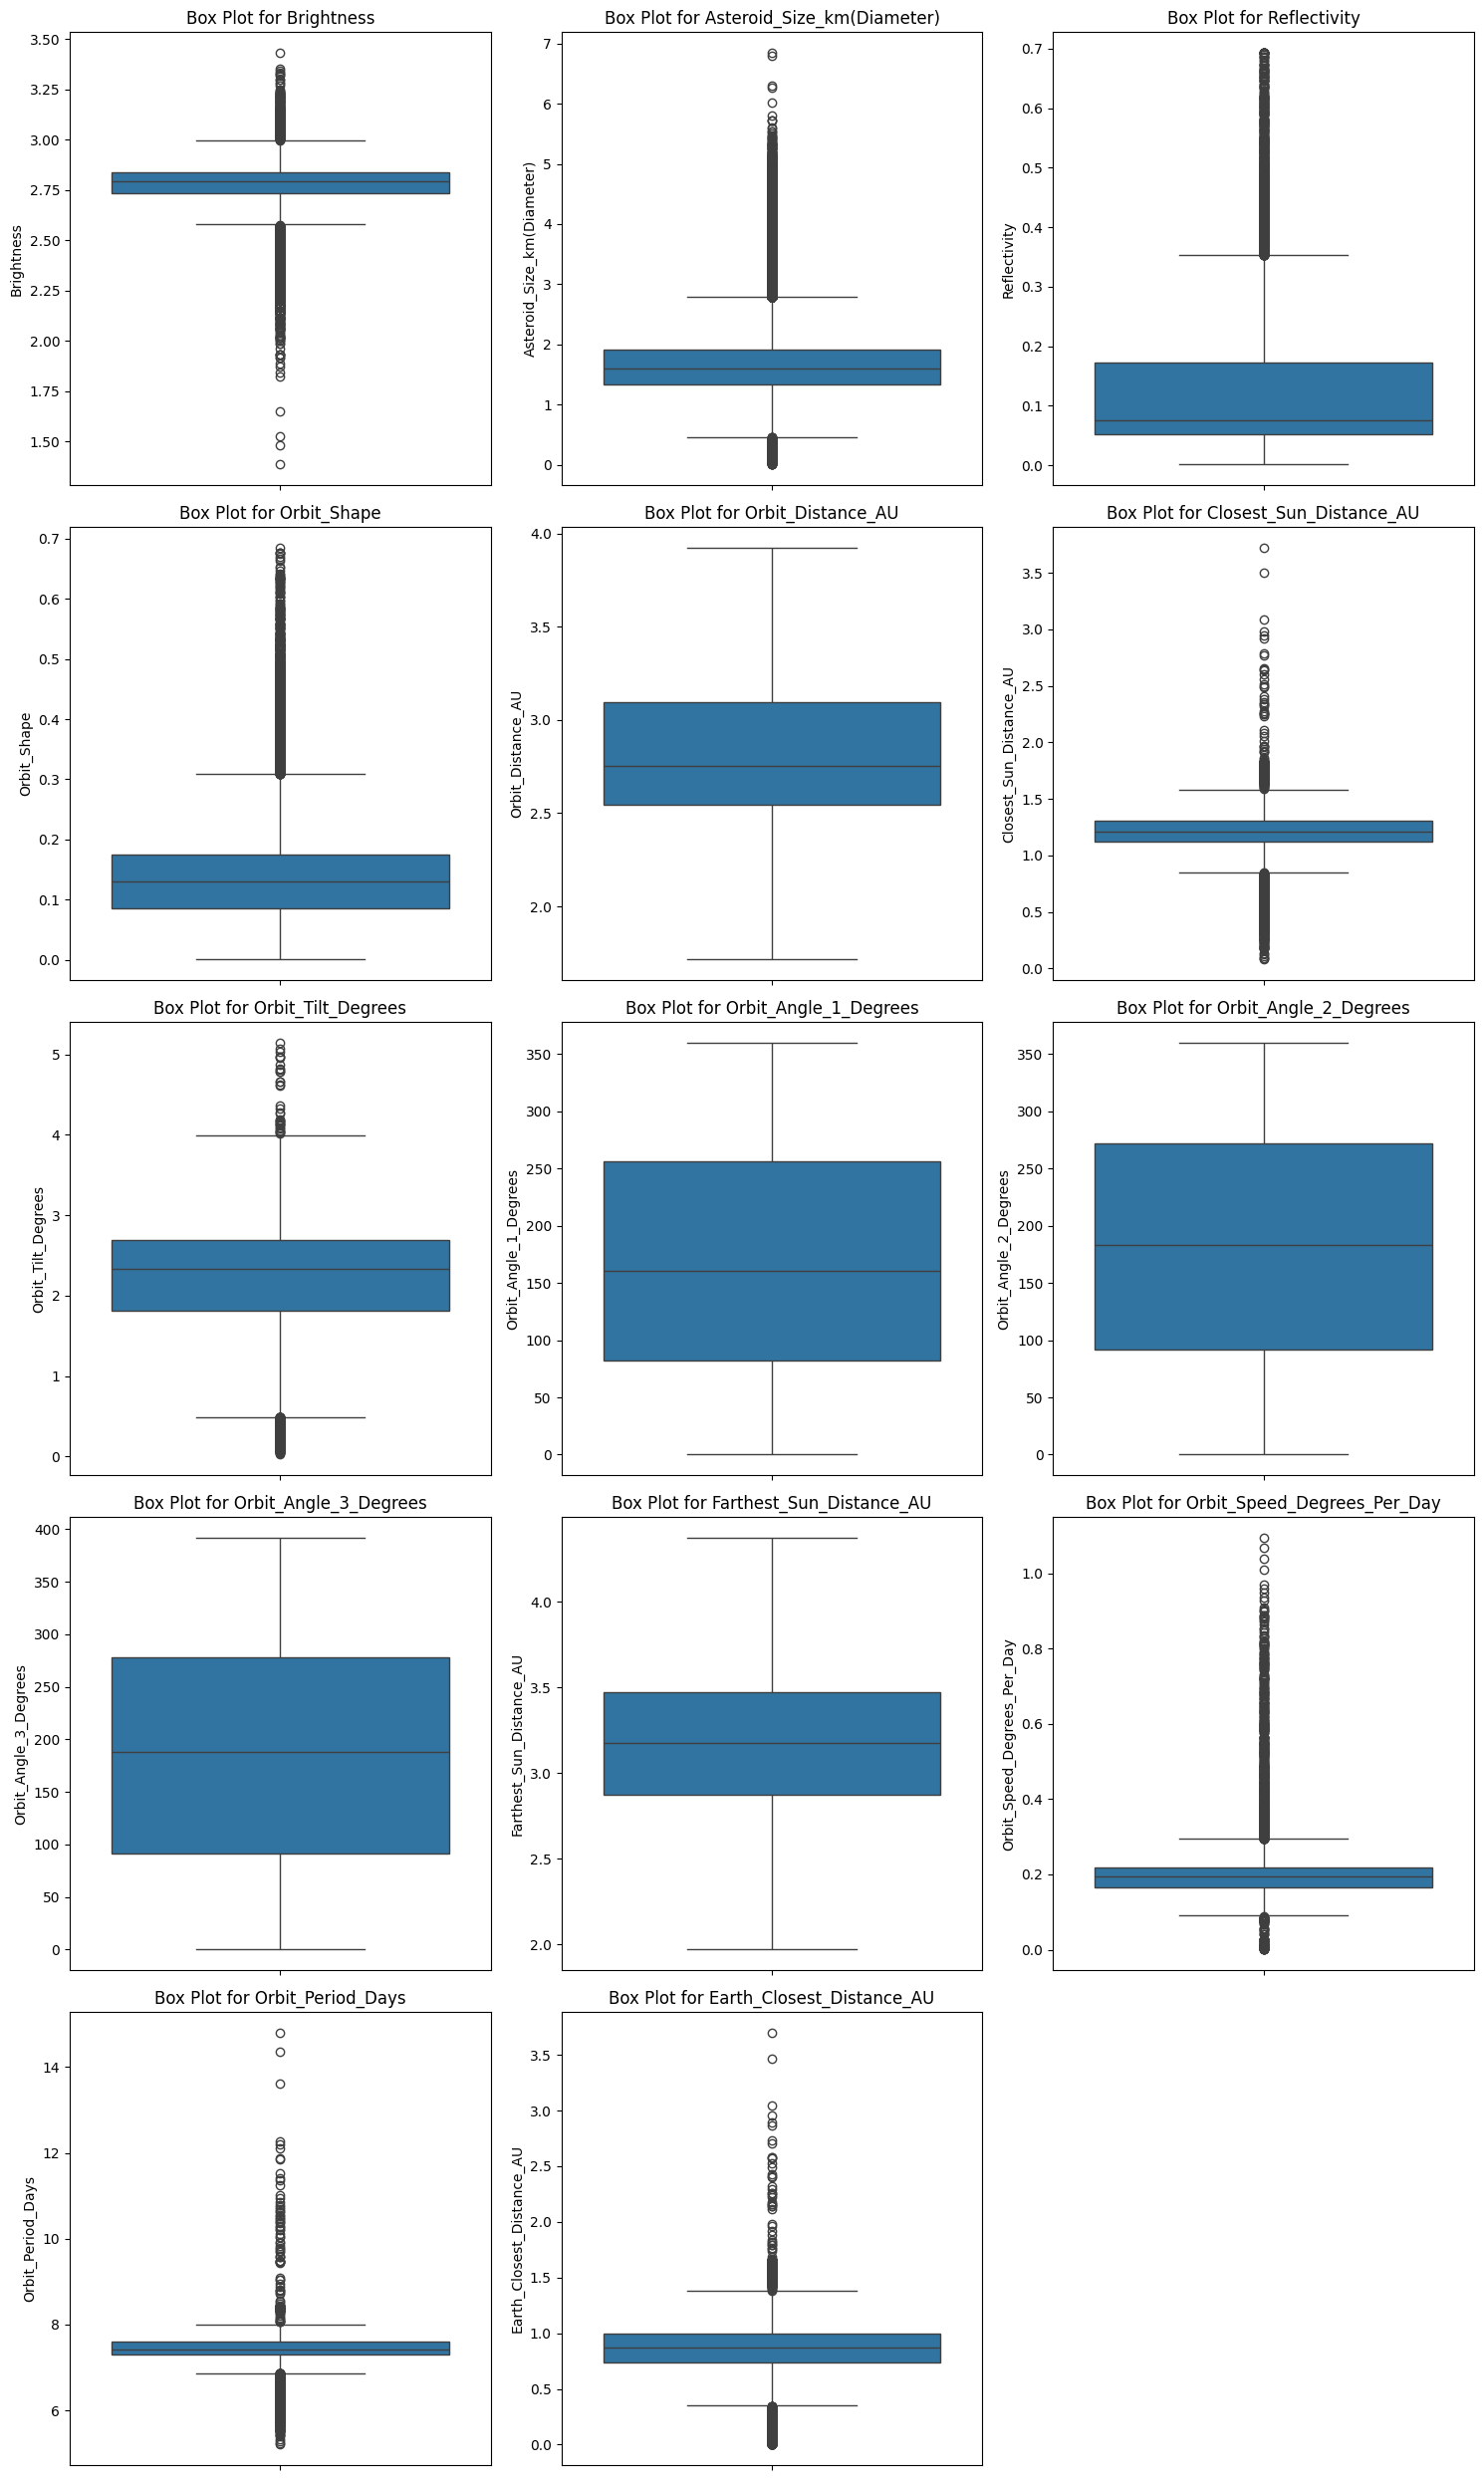

In [28]:
# Select only numerical columns
num_cols = df_regression.select_dtypes(include=['number']).columns

# Define grid layout (e.g., 3 columns and dynamic rows)
n_cols = 3  # Number of columns
n_rows = -(-len(num_cols) // n_cols)  # Ceiling division to calculate rows

# Create subplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 5 * n_rows))

# Flatten axes array if it's 2D
axes = axes.flatten()

# Create box plots for each numerical column
for i, column in enumerate(num_cols):
    sns.boxplot(y=df_regression[column], ax=axes[i])
    axes[i].set_title(f'Box Plot for {column}')

# Hide any empty subplots
for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

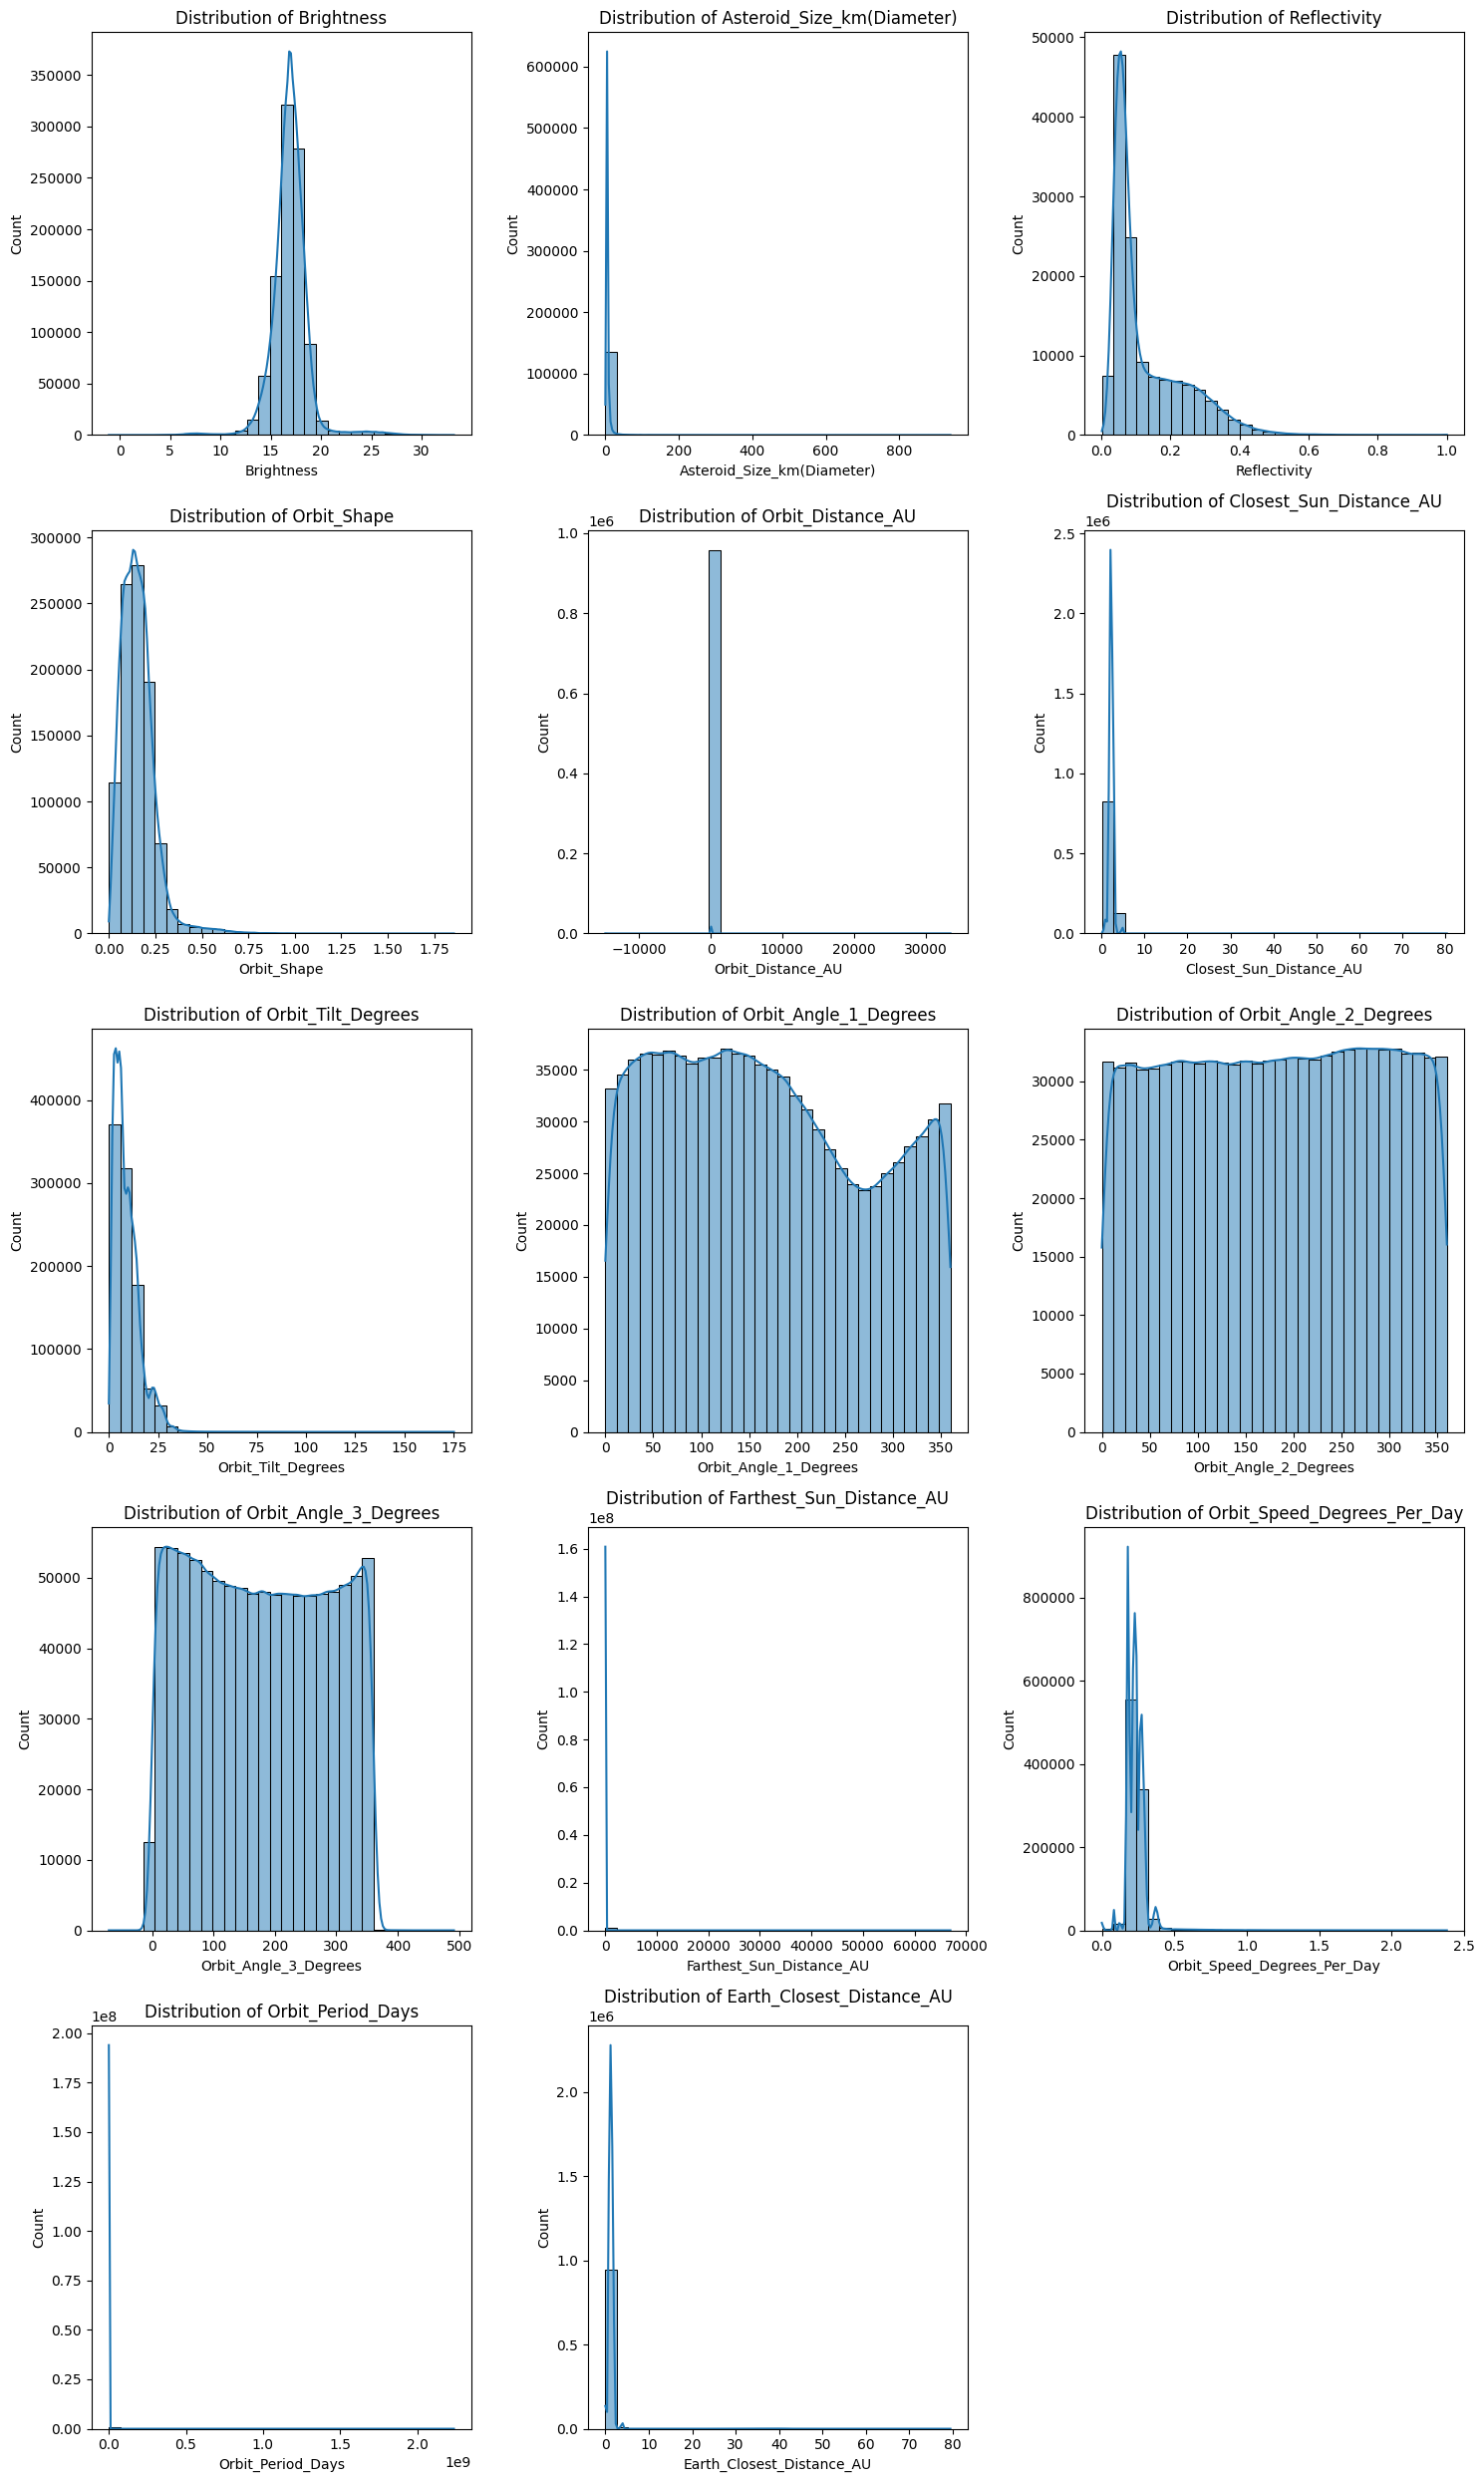

In [29]:
# Define grid layout (e.g., 3 columns and dynamic rows)
n_cols = 3  # Number of columns
n_rows = -(-len(num_cols) // n_cols)  # Ceiling division to calculate rows

# Create subplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 5 * n_rows))

# Flatten axes array if it's 2D
axes = axes.flatten()

# Create histograms for each numerical column
for i, column in enumerate(num_cols):
    sns.histplot(df[column], bins=30, kde=True, ax=axes[i])  # Histogram with KDE
    axes[i].set_title(f'Distribution of {column}')

# Hide any empty subplots
for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## Encoding

In [30]:
# Convert categorical columns to numerical using Label Encoding
df_numeric_regression_LE = df_regression.copy()

# Map Y/N to 1/0
df_numeric_regression_LE['Near_Earth_Object'] = df_numeric_regression_LE['Near_Earth_Object'].map({'Y': 1, 'N': 0})
df_numeric_regression_LE['Potentially_Hazardous'] = df_numeric_regression_LE['Potentially_Hazardous'].map({'Y': 1, 'N': 0})

# Encode Asteroid_Class using Label Encoding
label_encoder = LabelEncoder()
df_numeric_regression_LE['Asteroid_Class'] = label_encoder.fit_transform(df_numeric_regression_LE['Asteroid_Class'])

In [31]:
df_numeric_regression_LE.head()

,Near_Earth_Object,Potentially_Hazardous,Brightness,Asteroid_Size_km(Diameter),Reflectivity,Orbit_Shape,Orbit_Distance_AU,Closest_Sun_Distance_AU,Orbit_Tilt_Degrees,Orbit_Angle_1_Degrees,Orbit_Angle_2_Degrees,Orbit_Angle_3_Degrees,Farthest_Sun_Distance_AU,Orbit_Speed_Degrees_Per_Day,Orbit_Period_Days,Earth_Closest_Distance_AU,Asteroid_Class
0,0,0,1.481605,6.846305,0.086178,0.073259,2.769165,1.269391,2.450494,80.305531,73.597695,77.372098,2.979647,0.193826,7.429014,0.953502,6
1,0,0,1.648659,6.302619,0.096219,0.206992,2.773841,1.142927,3.578867,173.024741,310.202392,144.975675,3.411748,0.193381,7.431543,0.803924,6
2,0,0,1.845300,5.511798,0.193921,0.228677,2.668285,1.092831,2.638417,169.851482,248.066193,125.435355,3.353865,0.203862,7.373383,0.710147,6
3,0,0,1.386294,6.266061,0.352627,0.085004,2.361418,1.148008,2.097008,103.810804,150.728541,95.861938,2.570926,0.240283,7.190248,0.760563,6
4,0,0,2.066863,4.679340,0.242162,0.174721,2.574037,1.125780,1.851195,141.571026,358.648418,17.846343,3.065455,0.214031,7.319477,0.739911,6


In [32]:
df_numeric_regression_LE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 136209 entries, 0 to 909489
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Near_Earth_Object            136209 non-null  int64  
 1   Potentially_Hazardous        136209 non-null  int64  
 2   Brightness                   136209 non-null  float64
 3   Asteroid_Size_km(Diameter)   136209 non-null  float64
 4   Reflectivity                 136209 non-null  float64
 5   Orbit_Shape                  136209 non-null  float64
 6   Orbit_Distance_AU            136209 non-null  float64
 7   Closest_Sun_Distance_AU      136209 non-null  float64
 8   Orbit_Tilt_Degrees           136209 non-null  float64
 9   Orbit_Angle_1_Degrees        136209 non-null  float64
 10  Orbit_Angle_2_Degrees        136209 non-null  float64
 11  Orbit_Angle_3_Degrees        136209 non-null  float64
 12  Farthest_Sun_Distance_AU     136209 non-null  float64
 13  Orbi

In [33]:
# Convert categorical columns to numerical using One-Hot Encoding
df_numeric_regression_OHE = df_regression.copy()

# Map Y/N to 1/0
df_numeric_regression_OHE['Near_Earth_Object'] = df_numeric_regression_OHE['Near_Earth_Object'].map({'Y': 1, 'N': 0})
df_numeric_regression_OHE['Potentially_Hazardous'] = df_numeric_regression_OHE['Potentially_Hazardous'].map({'Y': 1, 'N': 0})

# Encode Asteroid_Class using One-Hot Encoding
df_numeric_regression_OHE = pd.get_dummies(df_numeric_regression_OHE, columns=['Asteroid_Class'], drop_first=True)

In [34]:
df_numeric_regression_OHE.head()

,Near_Earth_Object,Potentially_Hazardous,Brightness,Asteroid_Size_km(Diameter),Reflectivity,Orbit_Shape,Orbit_Distance_AU,Closest_Sun_Distance_AU,Orbit_Tilt_Degrees,Orbit_Angle_1_Degrees,...,Asteroid_Class_APO,Asteroid_Class_AST,Asteroid_Class_ATE,Asteroid_Class_CEN,Asteroid_Class_IMB,Asteroid_Class_MBA,Asteroid_Class_MCA,Asteroid_Class_OMB,Asteroid_Class_TJN,Asteroid_Class_TNO
0,0,0,1.481605,6.846305,0.086178,0.073259,2.769165,1.269391,2.450494,80.305531,...,False,False,False,False,False,True,False,False,False,False
1,0,0,1.648659,6.302619,0.096219,0.206992,2.773841,1.142927,3.578867,173.024741,...,False,False,False,False,False,True,False,False,False,False
2,0,0,1.845300,5.511798,0.193921,0.228677,2.668285,1.092831,2.638417,169.851482,...,False,False,False,False,False,True,False,False,False,False
3,0,0,1.386294,6.266061,0.352627,0.085004,2.361418,1.148008,2.097008,103.810804,...,False,False,False,False,False,True,False,False,False,False
4,0,0,2.066863,4.679340,0.242162,0.174721,2.574037,1.125780,1.851195,141.571026,...,False,False,False,False,False,True,False,False,False,False


In [35]:
df_numeric_regression_OHE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 136209 entries, 0 to 909489
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Near_Earth_Object            136209 non-null  int64  
 1   Potentially_Hazardous        136209 non-null  int64  
 2   Brightness                   136209 non-null  float64
 3   Asteroid_Size_km(Diameter)   136209 non-null  float64
 4   Reflectivity                 136209 non-null  float64
 5   Orbit_Shape                  136209 non-null  float64
 6   Orbit_Distance_AU            136209 non-null  float64
 7   Closest_Sun_Distance_AU      136209 non-null  float64
 8   Orbit_Tilt_Degrees           136209 non-null  float64
 9   Orbit_Angle_1_Degrees        136209 non-null  float64
 10  Orbit_Angle_2_Degrees        136209 non-null  float64
 11  Orbit_Angle_3_Degrees        136209 non-null  float64
 12  Farthest_Sun_Distance_AU     136209 non-null  float64
 13  Orbi

In [36]:
df_numeric_regression_OHE.describe().style.background_gradient(cmap = "YlGnBu")

,Near_Earth_Object,Potentially_Hazardous,Brightness,Asteroid_Size_km(Diameter),Reflectivity,Orbit_Shape,Orbit_Distance_AU,Closest_Sun_Distance_AU,Orbit_Tilt_Degrees,Orbit_Angle_1_Degrees,Orbit_Angle_2_Degrees,Orbit_Angle_3_Degrees,Farthest_Sun_Distance_AU,Orbit_Speed_Degrees_Per_Day,Orbit_Period_Days,Earth_Closest_Distance_AU
count,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000
mean,0.006233,0.001623,2.780156,1.669738,0.118069,0.133800,2.789230,1.215910,2.237792,169.729893,181.808169,184.529202,3.188101,0.197139,7.432229,0.867260
std,0.078704,0.040248,0.091544,0.523468,0.091106,0.065375,0.369155,0.136668,0.640352,102.715175,103.516287,105.632553,0.437640,0.042785,0.237107,0.186445
min,0.000000,0.000000,1.386294,0.002497,0.001000,0.000060,1.714597,0.078645,0.021817,0.000418,0.000130,0.005112,1.968785,0.000135,5.204006,0.000027
25%,0.000000,0.000000,2.734368,1.329724,0.051643,0.086066,2.542856,1.122485,1.806343,82.276476,91.903488,91.647097,2.871056,0.166372,7.301208,0.735354
50%,0.000000,0.000000,2.791165,1.603822,0.076035,0.130079,2.754950,1.214499,2.335603,160.301343,183.509496,188.275290,3.173515,0.195191,7.421298,0.871118
75%,0.000000,0.000000,2.839078,1.911762,0.172271,0.174940,3.095029,1.305159,2.685827,255.961202,271.642281,277.821001,3.472570,0.217580,7.595799,0.994140
max,1.000000,1.000000,3.430756,6.846305,0.693147,0.685009,3.923288,3.721310,5.143618,359.999793,359.998075,391.682098,4.374841,1.094922,14.795517,3.697847


## Visualization

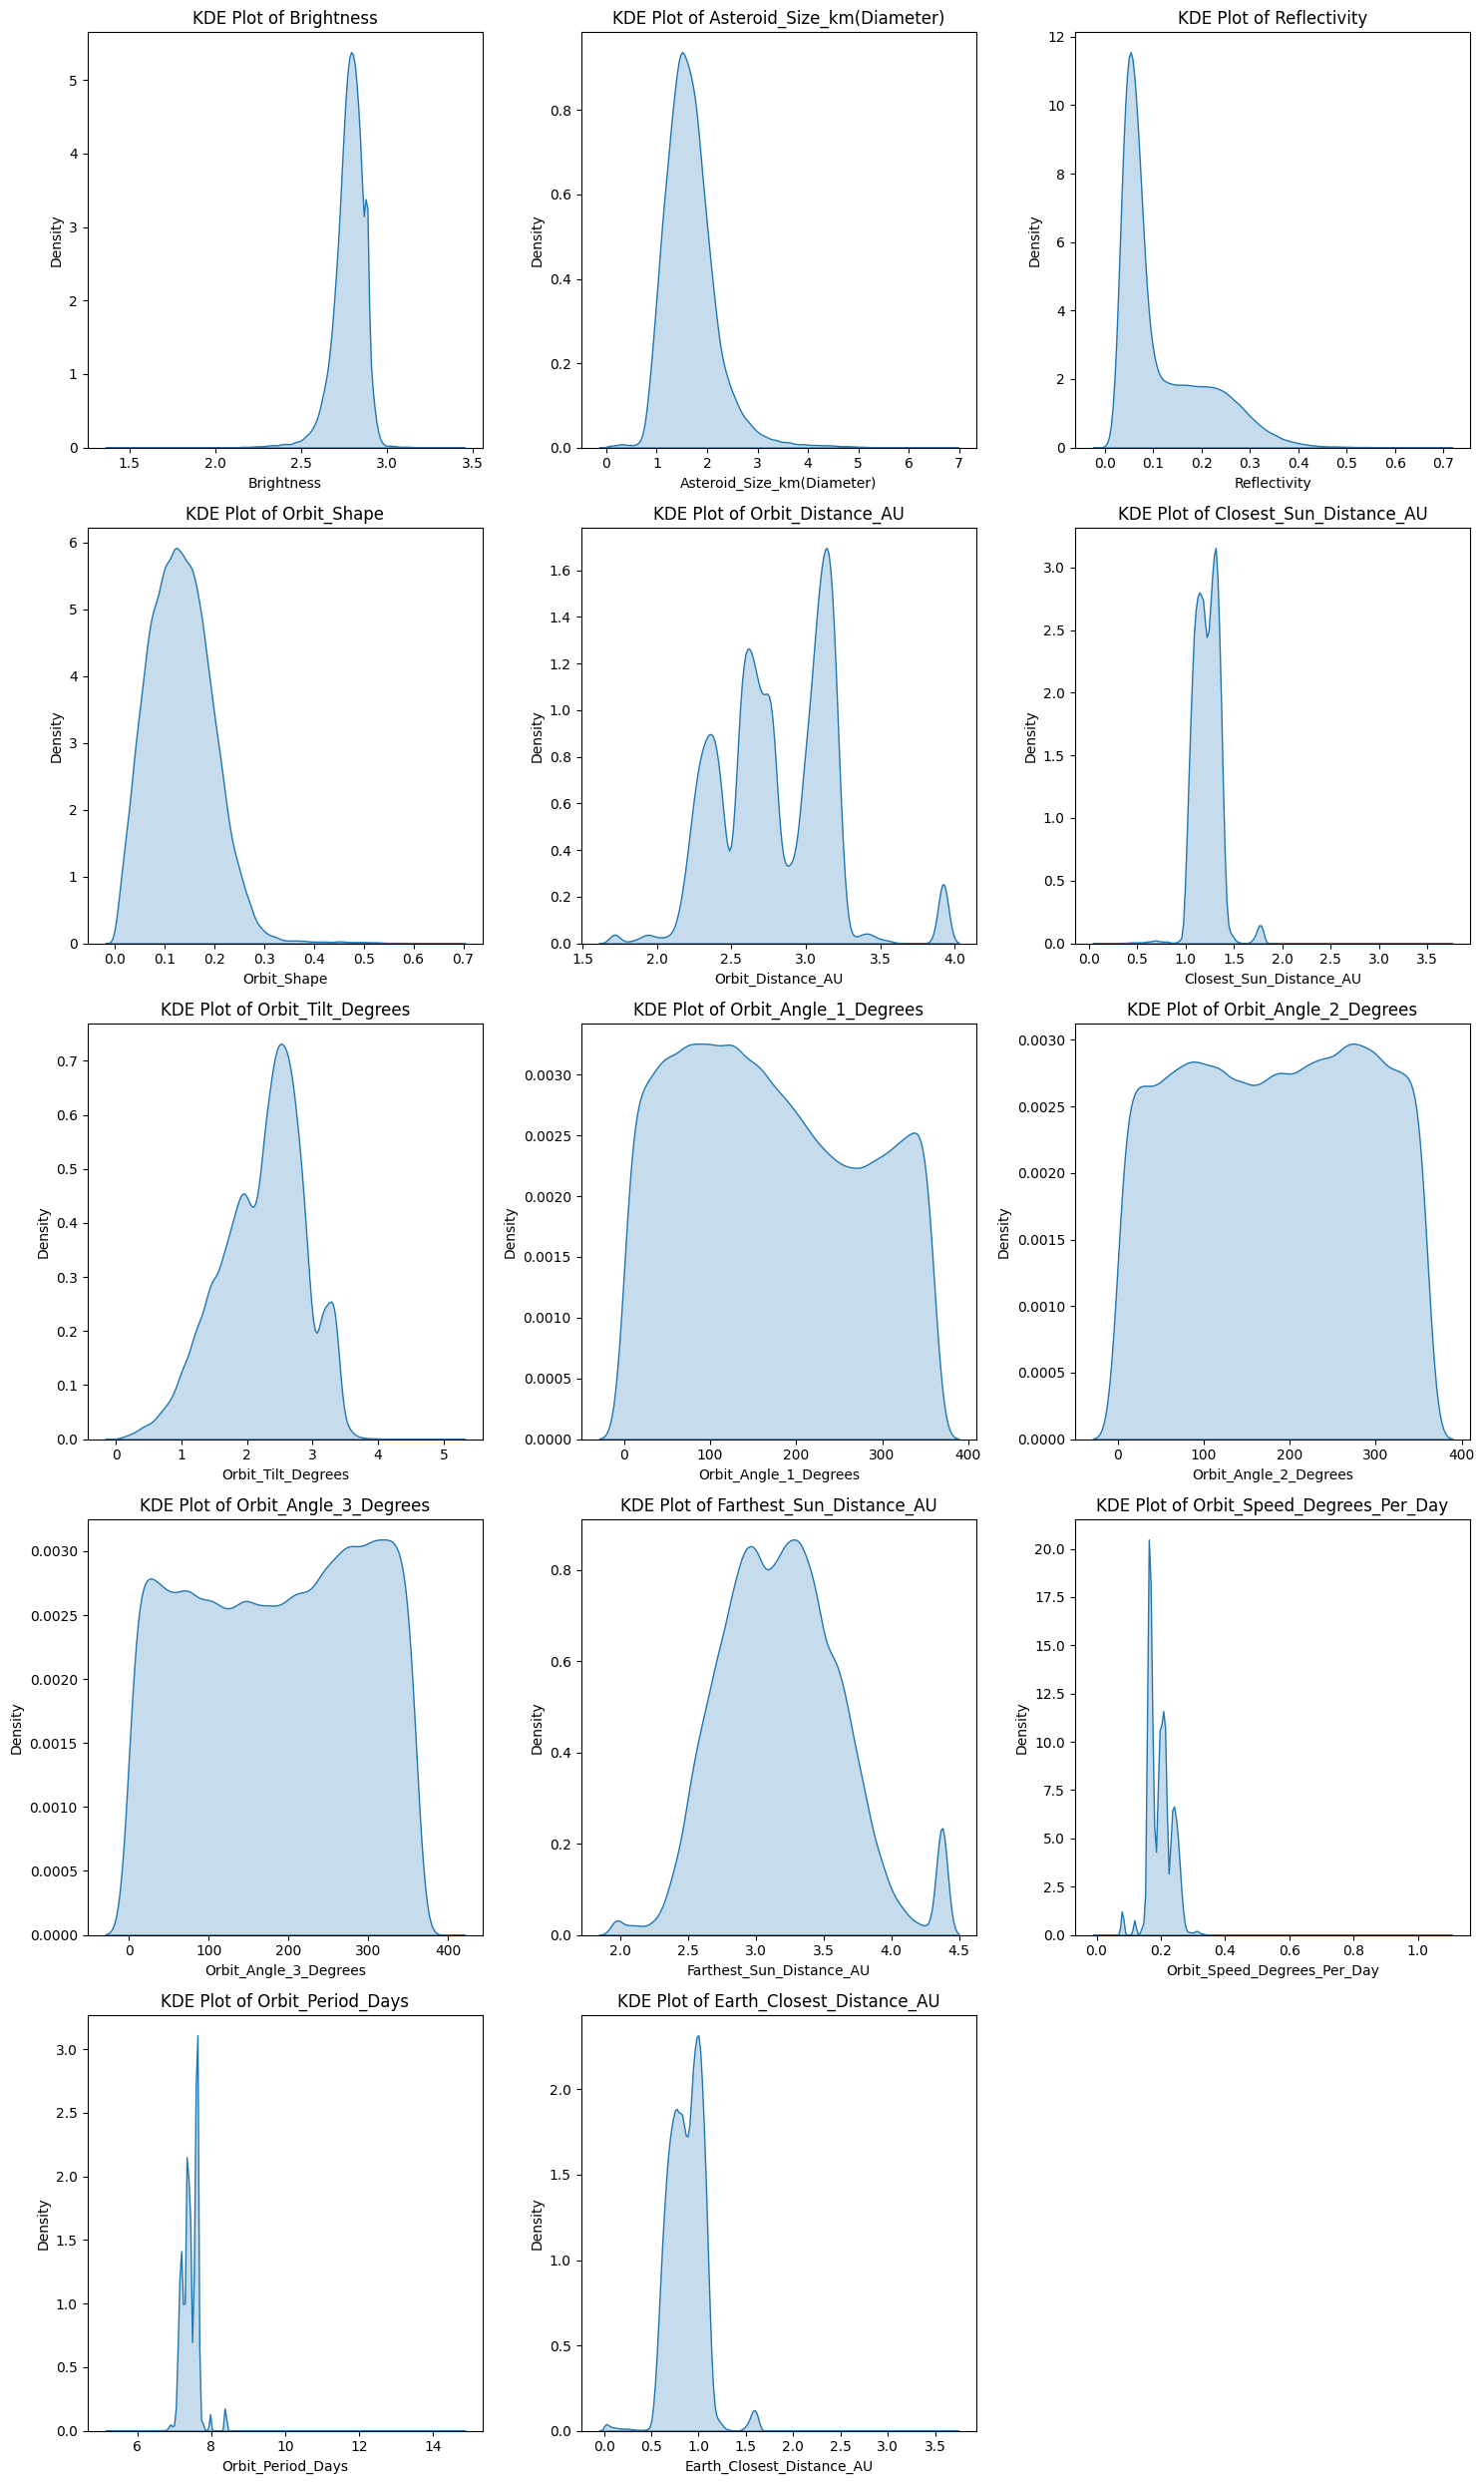

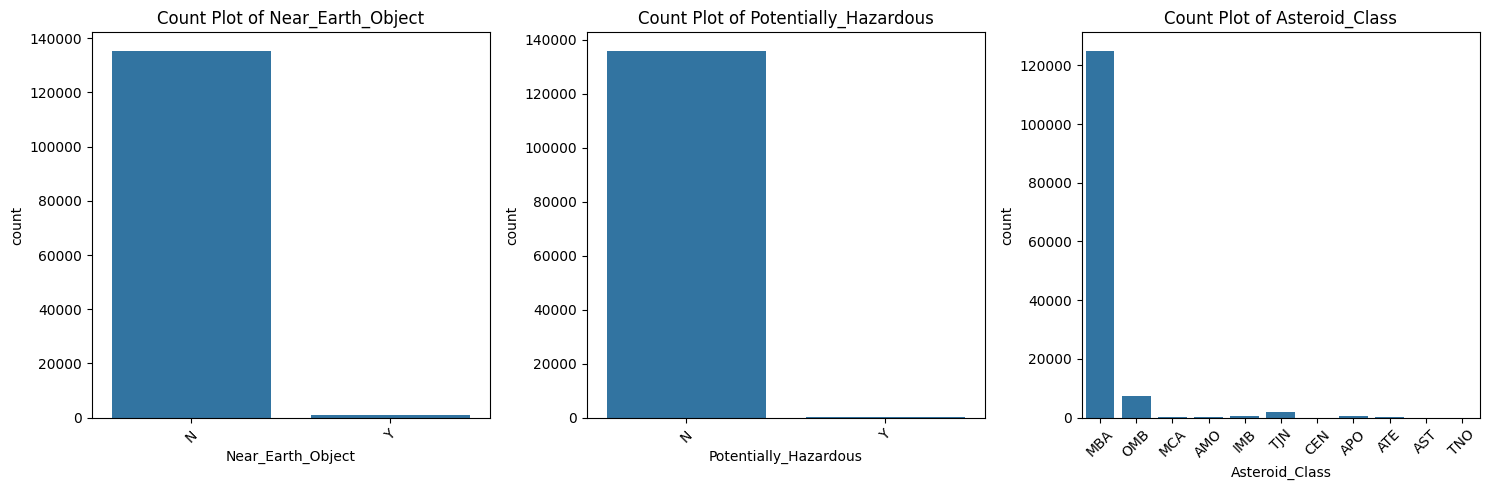

In [37]:
# Numerical columns (after log transformation)
num_cols = ['Brightness', 'Asteroid_Size_km(Diameter)', 'Reflectivity', 'Orbit_Shape',
            'Orbit_Distance_AU', 'Closest_Sun_Distance_AU', 'Orbit_Tilt_Degrees',
            'Orbit_Angle_1_Degrees', 'Orbit_Angle_2_Degrees', 'Orbit_Angle_3_Degrees',
            'Farthest_Sun_Distance_AU', 'Orbit_Speed_Degrees_Per_Day', 'Orbit_Period_Days',
            'Earth_Closest_Distance_AU']

# Categorical columns
cat_cols = ['Near_Earth_Object', 'Potentially_Hazardous', 'Asteroid_Class']

# 1. KDE Plots for Numerical Columns
n_cols = 3
n_rows = -(-len(num_cols) // n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, column in enumerate(num_cols):
    sns.kdeplot(data=df_regression[column], ax=axes[i], fill=True)
    axes[i].set_title(f'KDE Plot of {column}')

for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# 2. Count Plots for Categorical Columns
fig, axes = plt.subplots(nrows=1, ncols=len(cat_cols), figsize=(15, 5))
axes = axes.flatten()

for i, column in enumerate(cat_cols):
    sns.countplot(data=df_regression, x=column, ax=axes[i])
    axes[i].set_title(f'Count Plot of {column}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

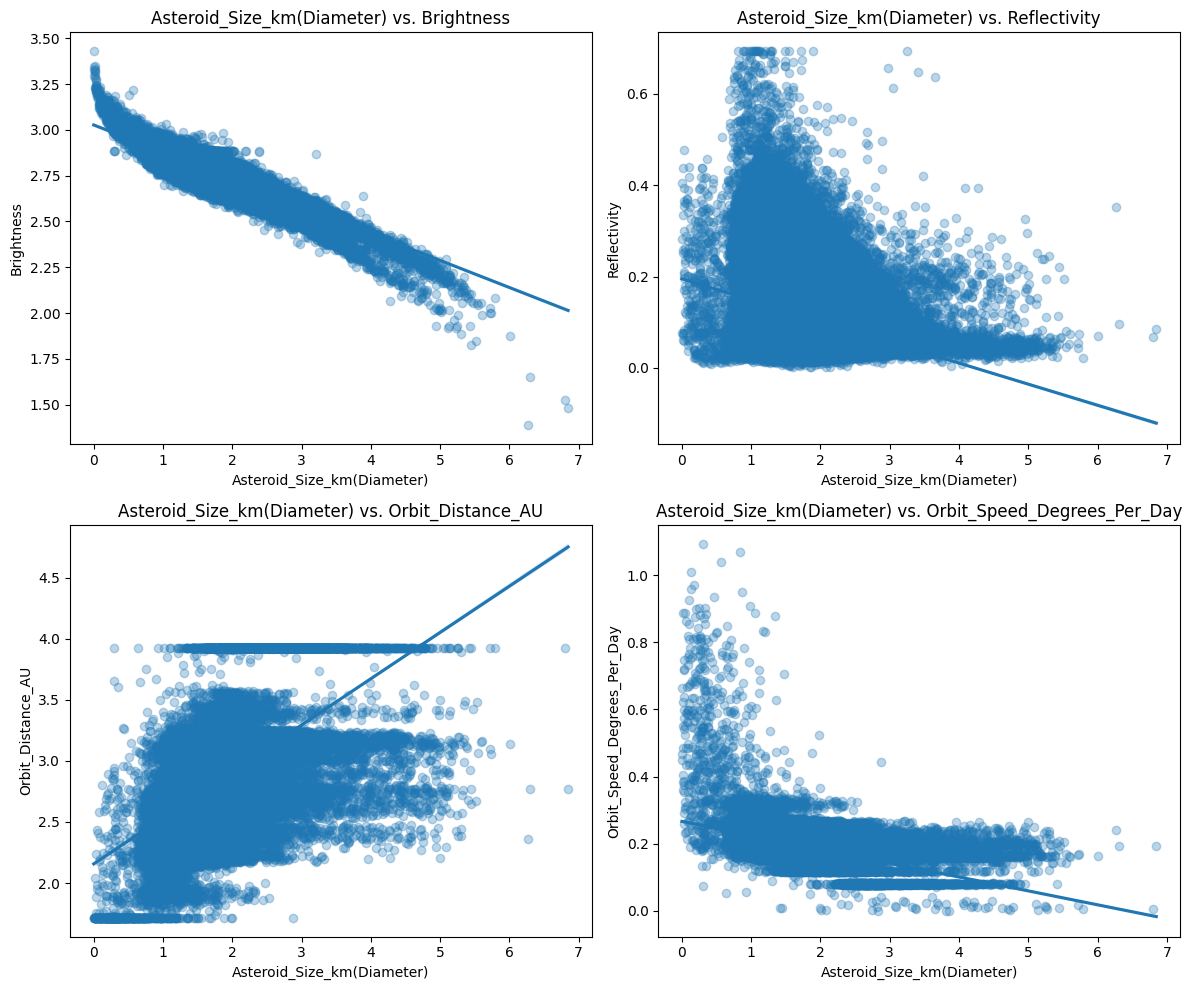

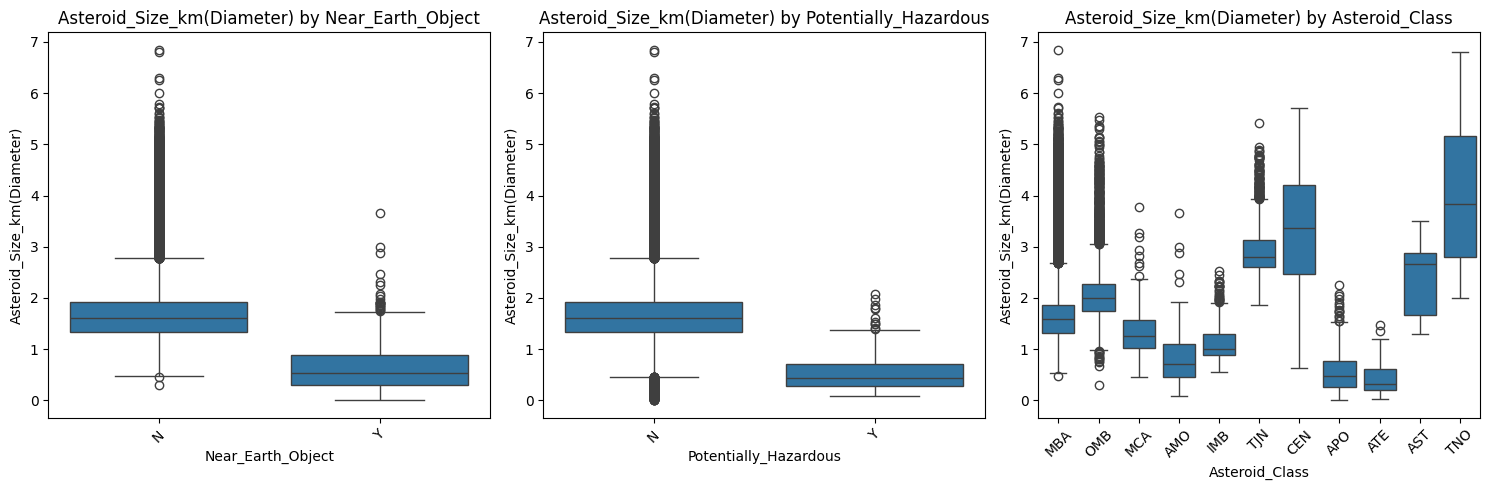

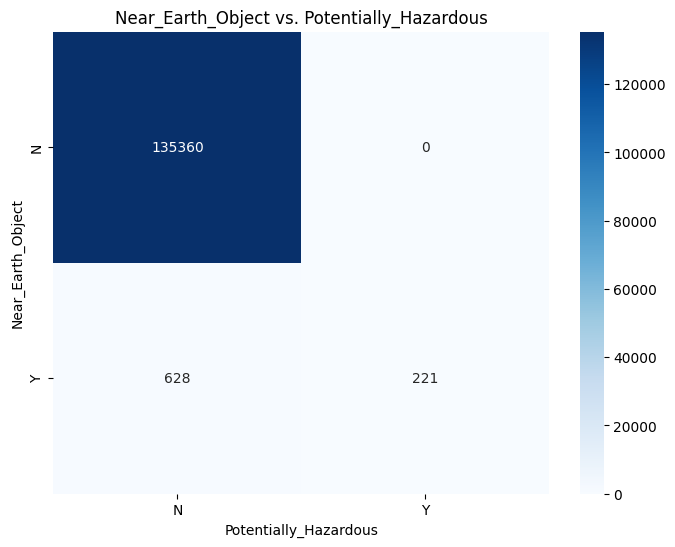

In [38]:
# 1. Numerical vs. Numerical: Scatter Plot with Regression Line
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

# Select a few numerical columns to compare with the target
num_pairs = [
    ('Asteroid_Size_km(Diameter)', 'Brightness'),
    ('Asteroid_Size_km(Diameter)', 'Reflectivity'),
    ('Asteroid_Size_km(Diameter)', 'Orbit_Distance_AU'),
    ('Asteroid_Size_km(Diameter)', 'Orbit_Speed_Degrees_Per_Day')
]

for i, (x_col, y_col) in enumerate(num_pairs):
    sns.regplot(data=df_regression, x=x_col, y=y_col, ax=axes[i], scatter_kws={'alpha':0.3})
    axes[i].set_title(f'{x_col} vs. {y_col}')

plt.tight_layout()
plt.show()

# 2. Numerical vs. Categorical: Box Plot
fig, axes = plt.subplots(nrows=1, ncols=len(cat_cols), figsize=(15, 5))
axes = axes.flatten()

for i, column in enumerate(cat_cols):
    sns.boxplot(data=df_regression, x=column, y='Asteroid_Size_km(Diameter)', ax=axes[i])
    axes[i].set_title(f'Asteroid_Size_km(Diameter) by {column}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 3. Categorical vs. Categorical: Heatmap of Contingency Table
# Example: Near_Earth_Object vs. Potentially_Hazardous
cross_tab = pd.crosstab(df_regression['Near_Earth_Object'], df_regression['Potentially_Hazardous'])
plt.figure(figsize=(8, 6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Near_Earth_Object vs. Potentially_Hazardous')
plt.show()

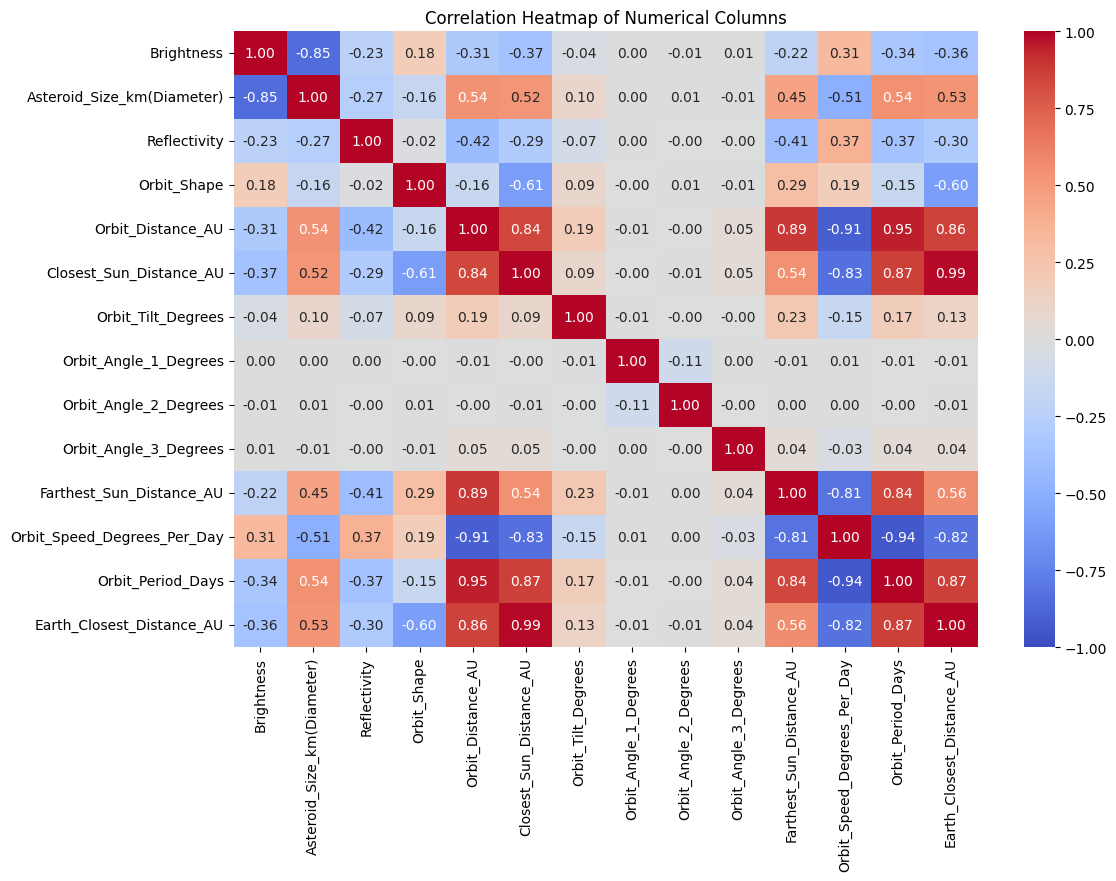

In [39]:
# 1. Correlation Heatmap for Numerical Columns
plt.figure(figsize=(12, 8))
corr_matrix = df_regression[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

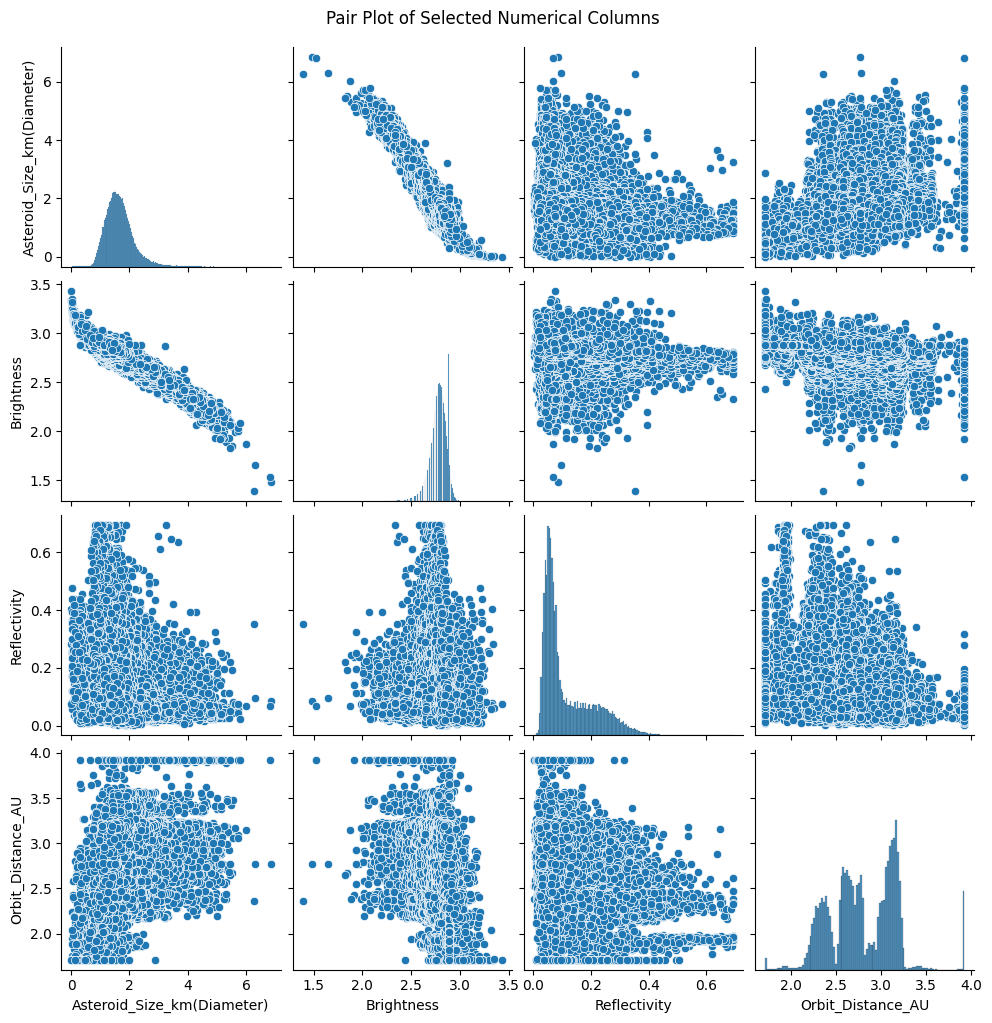

In [40]:
# 2. Pair Plot for a Subset of Numerical Columns (select a few for clarity)
subset_cols = ['Asteroid_Size_km(Diameter)', 'Brightness', 'Reflectivity', 'Orbit_Distance_AU']
sns.pairplot(df_regression[subset_cols])
plt.suptitle('Pair Plot of Selected Numerical Columns', y=1.02)
plt.show()

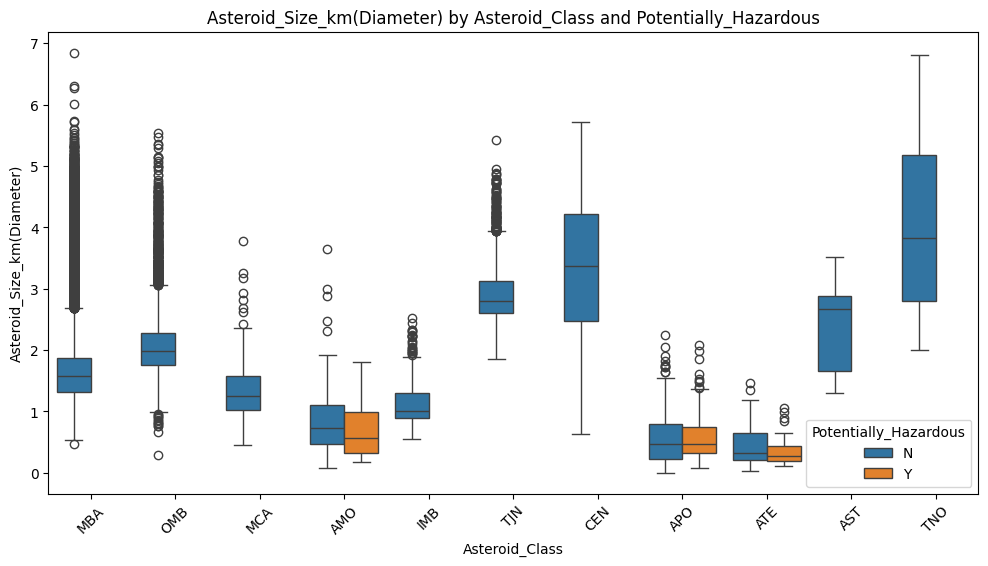

In [41]:
# 3. Grouped Box Plot: Asteroid_Size_km(Diameter) by Asteroid_Class and Potentially_Hazardous
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_regression, x='Asteroid_Class', y='Asteroid_Size_km(Diameter)', hue='Potentially_Hazardous')
plt.title('Asteroid_Size_km(Diameter) by Asteroid_Class and Potentially_Hazardous')
plt.xticks(rotation=45)
plt.show()

## Modelling

In [42]:
# Define features (exclude target 'Asteroid_Size_km(Diameter)')
X = df_numeric_regression_OHE.drop(columns=["Asteroid_Size_km(Diameter)"])
y = df_numeric_regression_OHE["Asteroid_Size_km(Diameter)"]

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (108967, 25)
X_test shape: (27242, 25)
y_train shape: (108967,)
y_test shape: (27242,)


### Random Forest Regressor

In [43]:
# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on train and test sets
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Calculate metrics
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
train_mse_rf = mean_squared_error(y_train, y_train_pred_rf)
train_r2_rf = r2_score(y_train, y_train_pred_rf)

test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

# Print results
print("Random Forest Regressor Results:")
print(f"Train MAE: {train_mae_rf:.4f}")
print(f"Train MSE: {train_mae_rf:.4f}")
print(f"Train R²: {train_r2_rf:.4f}")
print("------------------------------")
print(f"Test MAE: {test_mae_rf:.4f}")
print(f"Test MSE: {test_mse_rf:.4f}")
print(f"Test R²: {test_r2_rf:.4f}")

Random Forest Regressor Results:
Train MAE: 0.0222
Train MSE: 0.0222
Train R²: 0.9963
------------------------------
Test MAE: 0.0599
Test MSE: 0.0075
Test R²: 0.9730


In [47]:
print("X_train_const dtypes:")
print(X_train_const.dtypes)

print("\nAny object dtype columns:")
print(X_train_const.select_dtypes(include='object').columns)

print("\nAny NaNs:")
print(X_train_const.isnull().sum().sum(), "NaNs in X_train_const")
print(y_train.isnull().sum(), "NaNs in y_train")


X_train_const dtypes:
const                          float64
Near_Earth_Object                int64
Potentially_Hazardous            int64
Brightness                     float64
Reflectivity                   float64
Orbit_Shape                    float64
Orbit_Distance_AU              float64
Closest_Sun_Distance_AU        float64
Orbit_Tilt_Degrees             float64
Orbit_Angle_1_Degrees          float64
Orbit_Angle_2_Degrees          float64
Orbit_Angle_3_Degrees          float64
Farthest_Sun_Distance_AU       float64
Orbit_Speed_Degrees_Per_Day    float64
Orbit_Period_Days              float64
Earth_Closest_Distance_AU      float64
Asteroid_Class_APO                bool
Asteroid_Class_AST                bool
Asteroid_Class_ATE                bool
Asteroid_Class_CEN                bool
Asteroid_Class_IMB                bool
Asteroid_Class_MBA                bool
Asteroid_Class_MCA                bool
Asteroid_Class_OMB                bool
Asteroid_Class_TJN                bool
Ast

In [50]:
import statsmodels.api as sm

# Add constant
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Convert all columns to numeric
X_train_const = X_train_const.apply(pd.to_numeric, errors='coerce')
X_test_const = X_test_const.apply(pd.to_numeric, errors='coerce')
y_train = pd.to_numeric(y_train, errors='coerce')
y_test = pd.to_numeric(y_test, errors='coerce')

# Convert boolean columns to int/float (important!)
X_train_const = X_train_const.astype(float)
X_test_const = X_test_const.astype(float)

# Fit the model
glm_model = sm.GLM(y_train, X_train_const, family=sm.families.Gaussian()).fit()

# Train GLM with Gaussian family (linear regression)
glm_model = sm.GLM(y_train, X_train_const, family=sm.families.Gaussian()).fit()

# Predict
y_train_pred_glm = glm_model.predict(X_train_const)
y_test_pred_glm = glm_model.predict(X_test_const)

# Metrics
train_mae_glm = mean_absolute_error(y_train, y_train_pred_glm)
train_mse_glm = mean_squared_error(y_train, y_train_pred_glm)
train_r2_glm = r2_score(y_train, y_train_pred_glm)

test_mae_glm = mean_absolute_error(y_test, y_test_pred_glm)
test_mse_glm = mean_squared_error(y_test, y_test_pred_glm)
test_r2_glm = r2_score(y_test, y_test_pred_glm)

# Results
print("GLM Regressor (Gaussian) Results:")
print(f"Train MAE: {train_mae_glm:.4f}")
print(f"Train MSE: {train_mse_glm:.4f}")
print(f"Train R²: {train_r2_glm:.4f}")
print("------------------------------")
print(f"Test MAE: {test_mae_glm:.4f}")
print(f"Test MSE: {test_mse_glm:.4f}")
print(f"Test R²: {test_r2_glm:.4f}")


GLM Regressor (Gaussian) Results:
Train MAE: 0.0909
Train MSE: 0.0152
Train R²: 0.9444
------------------------------
Test MAE: 0.0913
Test MSE: 0.0155
Test R²: 0.9438


In [51]:
# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on train and test sets
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Calculate metrics
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
train_mse_lr = mean_squared_error(y_train, y_train_pred_lr)
train_r2_lr = r2_score(y_train, y_train_pred_lr)

test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)
test_mse_lr = mean_squared_error(y_test, y_test_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

# Print results
print("Linear Regression Results:")
print(f"Train MAE: {train_mae_lr:.4f}")
print(f"Train MSE: {train_mse_lr:.4f}")
print(f"Train R²: {train_r2_lr:.4f}")
print("------------------------------")
print(f"Test MAE: {test_mae_lr:.4f}")
print(f"Test MSE: {test_mse_lr:.4f}")
print(f"Test R²: {test_r2_lr:.4f}")

Linear Regression Results:
Train MAE: 0.0909
Train MSE: 0.0152
Train R²: 0.9444
------------------------------
Test MAE: 0.0913
Test MSE: 0.0155
Test R²: 0.9438


In [52]:
# Initialize and train the model
ridge_model = Ridge(alpha=0.01)
ridge_model.fit(X_train, y_train)

# Predict on train and test sets
y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge = ridge_model.predict(X_test)

# Calculate metrics
train_mae_ridge = mean_absolute_error(y_train, y_train_pred_ridge)
train_mse_ridge = mean_squared_error(y_train, y_train_pred_ridge)
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)

test_mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)
test_mse_ridge = mean_squared_error(y_test, y_test_pred_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)

# Print results
print("Ridge Regression Results:")
print(f"Train MAE: {train_mae_ridge:.4f}")
print(f"Train MSE: {train_mse_ridge:.4f}")
print(f"Train R²: {train_r2_ridge:.4f}")
print("------------------------------")
print(f"Test MAE: {test_mae_ridge:.4f}")
print(f"Test MSE: {test_mse_ridge:.4f}")
print(f"Test R²: {test_r2_ridge:.4f}")

Ridge Regression Results:
Train MAE: 0.0909
Train MSE: 0.0152
Train R²: 0.9444
------------------------------
Test MAE: 0.0913
Test MSE: 0.0155
Test R²: 0.9438
